In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
from sklearn.linear_model import LinearRegression,LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder


In [2]:
df=pd.read_csv("C:/Users/A/OneDrive/Desktop/Intenship/Womens Clothing E-Commerce Reviews.csv")
df

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses
...,...,...,...,...,...,...,...,...,...,...,...
23481,23481,1104,34,Great dress for many occasions,I was very happy to snag this dress at such a ...,5,1,0,General Petite,Dresses,Dresses
23482,23482,862,48,Wish it was made of cotton,"It reminds me of maternity clothes. soft, stre...",3,1,0,General Petite,Tops,Knits
23483,23483,1104,31,"Cute, but see through","This fit well, but the top was very see throug...",3,0,1,General Petite,Dresses,Dresses
23484,23484,1084,28,"Very cute dress, perfect for summer parties an...",I bought this dress for a wedding i have this ...,3,1,2,General,Dresses,Dresses


In [3]:
df.head(5)

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [4]:
df.tail(5)

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
23481,23481,1104,34,Great dress for many occasions,I was very happy to snag this dress at such a ...,5,1,0,General Petite,Dresses,Dresses
23482,23482,862,48,Wish it was made of cotton,"It reminds me of maternity clothes. soft, stre...",3,1,0,General Petite,Tops,Knits
23483,23483,1104,31,"Cute, but see through","This fit well, but the top was very see throug...",3,0,1,General Petite,Dresses,Dresses
23484,23484,1084,28,"Very cute dress, perfect for summer parties an...",I bought this dress for a wedding i have this ...,3,1,2,General,Dresses,Dresses
23485,23485,1104,52,Please make more like this one!,This dress in a lovely platinum is feminine an...,5,1,22,General Petite,Dresses,Dresses


Data Cleaning.

In [66]:
df.isnull().sum()

Unnamed: 0                    0
Clothing ID                   0
Age                           0
Title                      3810
Review Text                 845
Rating                        0
Recommended IND               0
Positive Feedback Count       0
Division Name                14
Department Name              14
Class Name                   14
dtype: int64

In [67]:
df.shape

(23486, 11)

In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Unnamed: 0               23486 non-null  int64 
 1   Clothing ID              23486 non-null  int64 
 2   Age                      23486 non-null  int64 
 3   Title                    19676 non-null  object
 4   Review Text              22641 non-null  object
 5   Rating                   23486 non-null  int64 
 6   Recommended IND          23486 non-null  int64 
 7   Positive Feedback Count  23486 non-null  int64 
 8   Division Name            23472 non-null  object
 9   Department Name          23472 non-null  object
 10  Class Name               23472 non-null  object
dtypes: int64(6), object(5)
memory usage: 2.0+ MB


In [3]:
df['Clothing ID'] = df['Clothing ID'].astype(str).str.replace(r'[+$_,]', '', regex=True)
df['Clothing ID'] = pd.to_numeric(df['Clothing ID'], errors='coerce')

df['Clothing ID']

0         767
1        1080
2        1077
3        1049
4         847
         ... 
23481    1104
23482     862
23483    1104
23484    1084
23485    1104
Name: Clothing ID, Length: 23486, dtype: int64

In [4]:

df = df.drop(columns=['Unnamed: 0'], errors='ignore')

print("removed unnamed column")

removed unnamed column


In [71]:
df.describe()

,Clothing ID,Age,Rating,Recommended IND,Positive Feedback Count
count,23486.000000,23486.000000,23486.000000,23486.000000,23486.000000
mean,918.118709,43.198544,4.196032,0.822362,2.535936
std,203.298980,12.279544,1.110031,0.382216,5.702202
min,0.000000,18.000000,1.000000,0.000000,0.000000
25%,861.000000,34.000000,4.000000,1.000000,0.000000
50%,936.000000,41.000000,5.000000,1.000000,1.000000
75%,1078.000000,52.000000,5.000000,1.000000,3.000000
max,1205.000000,99.000000,5.000000,1.000000,122.000000


Exploring Data:

In [72]:
numerics_features=[features for features in df.columns if df[features].dtype!="O"]#check numeric in O is object
numerics_features

['Clothing ID', 'Age', 'Rating', 'Recommended IND', 'Positive Feedback Count']

In [73]:
categorical_features=[features for features in df.columns if df[features].dtype =="O"]#categorical data
categorical_features


['Title', 'Review Text', 'Division Name', 'Department Name', 'Class Name']

In [74]:
df['Title'].unique()

array([nan, 'Some major design flaws', 'My favorite buy!', ...,
       'Cute, but see through',
       'Very cute dress, perfect for summer parties and we',
       'Please make more like this one!'], shape=(13994,), dtype=object)

In [75]:
df['Review Text'].unique()

array(['Absolutely wonderful - silky and sexy and comfortable',
       'Love this dress!  it\'s sooo pretty.  i happened to find it in a store, and i\'m glad i did bc i never would have ordered it online bc it\'s petite.  i bought a petite and am 5\'8".  i love the length on me- hits just a little below the knee.  would definitely be a true midi on someone who is truly petite.',
       'I had such high hopes for this dress and really wanted it to work for me. i initially ordered the petite small (my usual size) but i found this to be outrageously small. so small in fact that i could not zip it up! i reordered it in petite medium, which was just ok. overall, the top half was comfortable and fit nicely, but the bottom half had a very tight under layer and several somewhat cheap (net) over layers. imo, a major design flaw was the net over layer sewn directly into the zipper - it c',
       ...,
       "This fit well, but the top was very see through. this never would have worked for me. i

In [76]:
df['Division Name'].unique()

array(['Initmates', 'General', 'General Petite', nan], dtype=object)

In [77]:
df['Department Name'].unique()

array(['Intimate', 'Dresses', 'Bottoms', 'Tops', 'Jackets', 'Trend', nan],
      dtype=object)

In [78]:
df['Class Name'].unique()

array(['Intimates', 'Dresses', 'Pants', 'Blouses', 'Knits', 'Outerwear',
       'Lounge', 'Sweaters', 'Skirts', 'Fine gauge', 'Sleep', 'Jackets',
       'Swim', 'Trend', 'Jeans', 'Legwear', 'Shorts', 'Layering',
       'Casual bottoms', nan, 'Chemises'], dtype=object)

In [79]:
le = LabelEncoder()

#Division Name
mask1 = df['Division Name'].notnull()
df.loc[mask1, 'division_enc'] = le.fit_transform(df.loc[mask1, 'Division Name'])

# Department Name 
mask2 = df['Department Name'].notnull()
df.loc[mask2, 'department_enc'] = le.fit_transform(df.loc[mask2, 'Department Name'])

# Class Name 
mask3 = df['Class Name'].notnull()
df.loc[mask3, 'class_enc'] = le.fit_transform(df.loc[mask3, 'Class Name'])

#### Task 1: Handle missing values in the dataset using multiple imputation techniques, such as KNN imputation, MICE, and predictive modeling, manually selecting the best method for each column based on statistical analysis.

 multiple imputation techniques

In [80]:
from sklearn.impute import KNNImputer

In [81]:
imputer = KNNImputer(n_neighbors=5)
df[['division_enc', 'department_enc', 'class_enc']] = imputer.fit_transform(df[['division_enc', 'department_enc', 'class_enc']])

print(df[['Division Name', 'division_enc']].head(5))

print("\n--- Department Name comparison ---")
print(df[['Department Name', 'department_enc']].head(5))

print("\n--- Class Name comparison ---")
print(df[['Class Name', 'class_enc']].head(5))

    Division Name  division_enc
0       Initmates           2.0
1         General           0.0
2         General           0.0
3  General Petite           1.0
4         General           0.0

--- Department Name comparison ---
  Department Name  department_enc
0        Intimate             2.0
1         Dresses             1.0
2         Dresses             1.0
3         Bottoms             0.0
4            Tops             4.0

--- Class Name comparison ---
  Class Name  class_enc
0  Intimates        5.0
1    Dresses        3.0
2    Dresses        3.0
3      Pants       13.0
4    Blouses        0.0


MICE Imputation

In [82]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

In [83]:
mice = IterativeImputer(random_state=42)
df['div_mice'] = mice.fit_transform(df[['division_enc']])

In [84]:
df['div_pred'] = df['division_enc'].fillna(df['division_enc'].mean())

In [85]:
print("--- Statistical Analysis (Mean Comparison) ---")
print(f"Original Mean  : {df['division_enc'].mean():.4f}")#.4f means . after only 4 digit display
print(f"KNN Mean       : {df['division_enc'].mean():.4f}") 
print(f"MICE Mean      : {df['div_mice'].mean():.4f}")
print(f"Predictive Mean: {df['div_pred'].mean():.4f}")

--- Statistical Analysis (Mean Comparison) ---
Original Mean  : 0.4739
KNN Mean       : 0.4739
MICE Mean      : 0.4739
Predictive Mean: 0.4739


Custom Data Cleaning Pipeline

In [86]:
bf=len(df)
bf

23486

In [87]:
df = df.drop_duplicates()
af=len(df)
print(af)

23465


In [88]:
print(df.columns)

Index(['Clothing ID', 'Age', 'Title', 'Review Text', 'Rating',
       'Recommended IND', 'Positive Feedback Count', 'Division Name',
       'Department Name', 'Class Name', 'division_enc', 'department_enc',
       'class_enc', 'div_mice', 'div_pred'],
      dtype='object')


#### Task-3 Standardize column names and correct data types by implementing a dynamic parser that automatically detects and converts incorrect formats, ensuring consistency across the entire dataset without introducing errors.

In [5]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [21]:
df

,unnamed:_0,clothing_id,age,title,review_text,rating,recommended_ind,positive_feedback_count,division_name,department_name,class_name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses
...,...,...,...,...,...,...,...,...,...,...,...
23481,23481,1104,34,Great dress for many occasions,I was very happy to snag this dress at such a ...,5,1,0,General Petite,Dresses,Dresses
23482,23482,862,48,Wish it was made of cotton,"It reminds me of maternity clothes. soft, stre...",3,1,0,General Petite,Tops,Knits
23483,23483,1104,31,"Cute, but see through","This fit well, but the top was very see throug...",3,0,1,General Petite,Dresses,Dresses
23484,23484,1084,28,"Very cute dress, perfect for summer parties an...",I bought this dress for a wedding i have this ...,3,1,2,General,Dresses,Dresses


In [90]:
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
df['age'] = pd.to_numeric(df['age'], errors='coerce')

In [91]:
print("--- Standardized Column Names ---")
print(df.columns.tolist())

print("\n--- Corrected Data Types ---")
print(df.dtypes.head())

--- Standardized Column Names ---
['clothing_id', 'age', 'title', 'review_text', 'rating', 'recommended_ind', 'positive_feedback_count', 'division_name', 'department_name', 'class_name', 'division_enc', 'department_enc', 'class_enc', 'div_mice', 'div_pred']

--- Corrected Data Types ---
clothing_id     int64
age             int64
title          object
review_text    object
rating          int64
dtype: object


In [92]:
df.columns

Index(['clothing_id', 'age', 'title', 'review_text', 'rating',
       'recommended_ind', 'positive_feedback_count', 'division_name',
       'department_name', 'class_name', 'division_enc', 'department_enc',
       'class_enc', 'div_mice', 'div_pred'],
      dtype='object')

#### Task-4: Deal with outliers in numerical columns by applying multiple detection methods (IQR, Z-score, DBSCAN clustering) and deciding case-by-case whether to cap, transform, or remove extreme values based on domain-specific insights.

In [93]:
from scipy import stats
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

In [94]:
#IQR:

Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)
IQR = Q3 - Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

In [95]:
# Z-score Method

z_scores = np.abs(stats.zscore(df['age']))
z_outliers = np.where(z_scores > 3)

In [96]:
#DBSCAN Clustering

scaler = StandardScaler()
age_scaled = scaler.fit_transform(df[['age']])
dbscan = DBSCAN(eps=0.5, min_samples=5)
clusters = dbscan.fit_predict(age_scaled)
# -1 means outlier
dbscan_outliers = np.where(clusters == -1)

In [97]:
print("--- Outlier Detection Log ---")
print(f"IQR Upper Limit: {upper_limit}")
print(f"Z-score Outliers count: {len(z_outliers[0])}")
print(f"DBSCAN Outliers count: {len(dbscan_outliers[0])}")
print("Decision: Capping method applied to preserve data.")

--- Outlier Detection Log ---
IQR Upper Limit: 79.0
Z-score Outliers count: 99
DBSCAN Outliers count: 0
Decision: Capping method applied to preserve data.


In [98]:
#Handling (Capping)
df['age'] = np.where(df['age'] > upper_limit, upper_limit, df['age'])


In [99]:
print(f"IQR Upper Limit: {upper_limit}")
print(f"Z-score Outliers: {len(z_outliers[0])}")
print(f"DBSCAN Outliers: {list(clusters).count(-1)}")

IQR Upper Limit: 79.0
Z-score Outliers: 99
DBSCAN Outliers: 0


Task-5:Normalize or scale numerical features for consistency by testing multiple scaling techniques (Min-Max, StandardScaler, RobustScaler, Power Transform) and selecting the most suitable approach for preserving data distributions while optimizing model performance.

In [100]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, PowerTransformer

In [101]:
h = ['age', 'positive_feedback_count']

df_minmax = MinMaxScaler().fit_transform(df[h])
df_std = StandardScaler().fit_transform(df[h])
df_robust = RobustScaler().fit_transform(df[h])
df_power = PowerTransformer().fit_transform(df[h])

print(f"Original SD: {df[h].std().values}")
print(f"StandScaler SD:   {df_std.std()}")
print(f"Min-Max SD:  {df_minmax.std()}")
print(f"Robust SD:   {df_robust.std()}")
print(f"Power Transform SD:   {df_power.std()}")

df_final = df.copy()

df_final[h] = df_robust

print("\nDecision: RobustScaler applied on 'df_final'. Original 'df' remains safe for visualization!")

Original SD: [12.19696498  5.7042477 ]
StandScaler SD:   1.0
Min-Max SD:  0.24387918231724276
Robust SD:   1.4406885650560963
Power Transform SD:   0.9999999999999999

Decision: RobustScaler applied on 'df_final'. Original 'df' remains safe for visualization!


## EDA

### Task-1: Visualization: Numeric value only

In [102]:
import seaborn as sns

Rating Skewness: -1.31
Rating Kurtosis: 0.80


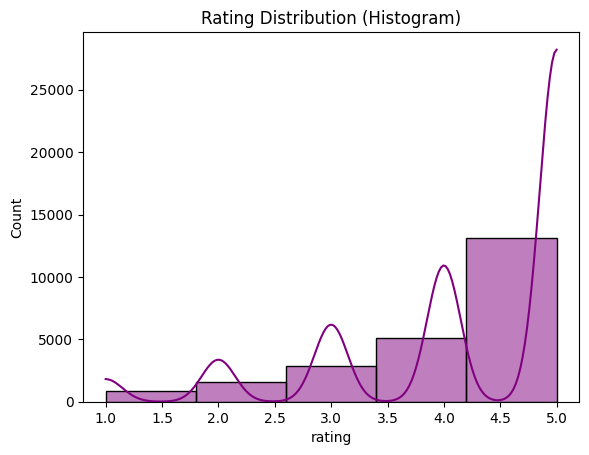

In [103]:
print(f"Rating Skewness: {df['rating'].skew():.2f}")
print(f"Rating Kurtosis: {df['rating'].kurt():.2f}")


sns.histplot(df['rating'], kde=True, color='purple', bins=5)
plt.title('Rating Distribution (Histogram)')
plt.show()



"This histogram shows how many customers gave each rating from 1 to 5."
"The high bars on the right side (4 and 5) mean that most customers are happy with the products."

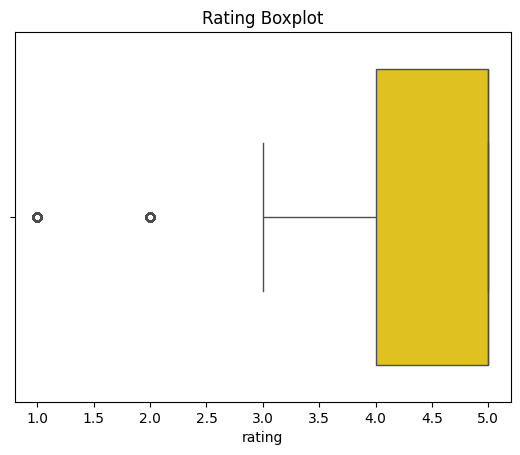

In [104]:
sns.boxplot(x=df['rating'], color='gold')
plt.title('Rating Boxplot')
plt.show()

"The boxplot shows the spread of ratings."
"The yellow box represents where most of the ratings lie."
"If you see dots on the left side, it means some customers gave much lower ratings compared to others."

##  Age For:

In [105]:
print(f"Age Skewness: {df['age'].skew():.2f}")
print(f"Age Kurtosis: {df['age'].kurt():.2f}")

Age Skewness: 0.47
Age Kurtosis: -0.33


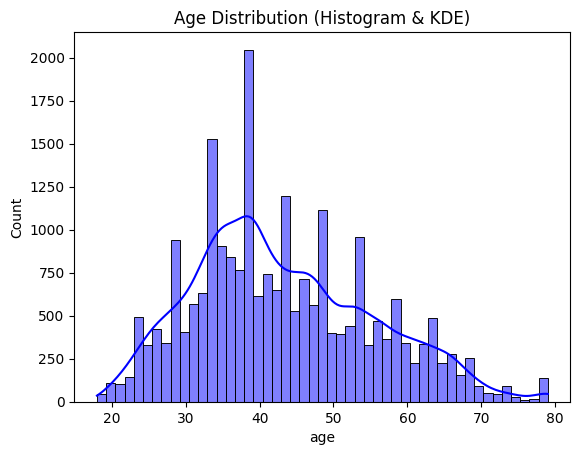

In [106]:
sns.histplot(df['age'], kde=True, color='blue')
plt.title('Age Distribution (Histogram & KDE)')
plt.show()

This graph shows the age groups of our customers. It helps us see which age is the most common and how the data is spread from youngest to oldest.

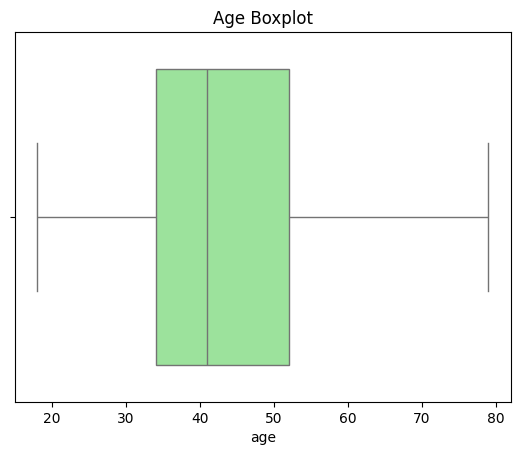

In [107]:
sns.boxplot(x=df['age'], color='lightgreen')
plt.title('Age Boxplot')
plt.show()

"This boxplot shows the spread and range of customer ages."
"The blue box shows where the middle 50% of customers fall."
"The dots outside the lines represent 'Outliers'—customers who are much older or younger than the average."

## positive_feedback_count

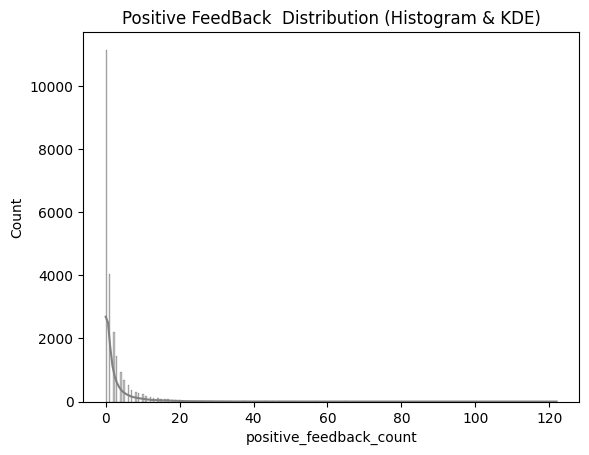

In [108]:
sns.histplot(df['positive_feedback_count'],kde=True,color='Grey')
plt.title("Positive FeedBack  Distribution (Histogram & KDE)")
plt.show()

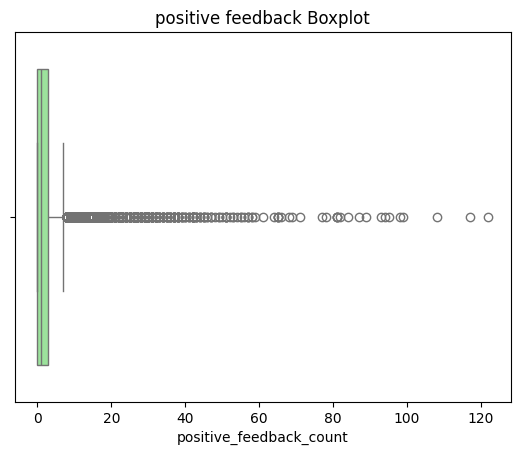

In [109]:
sns.boxplot(x=df['positive_feedback_count'], color='lightgreen')
plt.title('positive feedback Boxplot')
plt.show()

#### Task 2: Perform univariate analysis on categorical columns by creating frequency distributions, encoding high-cardinality categories dynamically, and visualizing trends using stacked bar charts, pie charts, and entropy-based category importance measures.

## Categorical Column Visulization

### Department_name 

C:\Users\A\AppData\Local\Temp\ipykernel_15112\4094102038.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=x_values, y=y_values, palette='viridis')


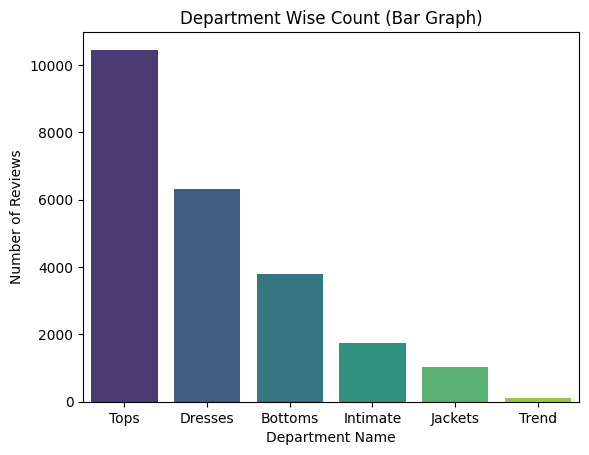

In [111]:
counts = df['department_name'].value_counts()
x_values = counts.index   
y_values = counts.values  


sns.barplot(x=x_values, y=y_values, palette='viridis')
plt.title('Department Wise Count (Bar Graph)')
plt.xlabel('Department Name')
plt.ylabel('Number of Reviews')
plt.show()



"This bar graph shows the total number of reviews for each department.The X-axis shows the department names, and the Y-axis shows how many times they appear in our data."



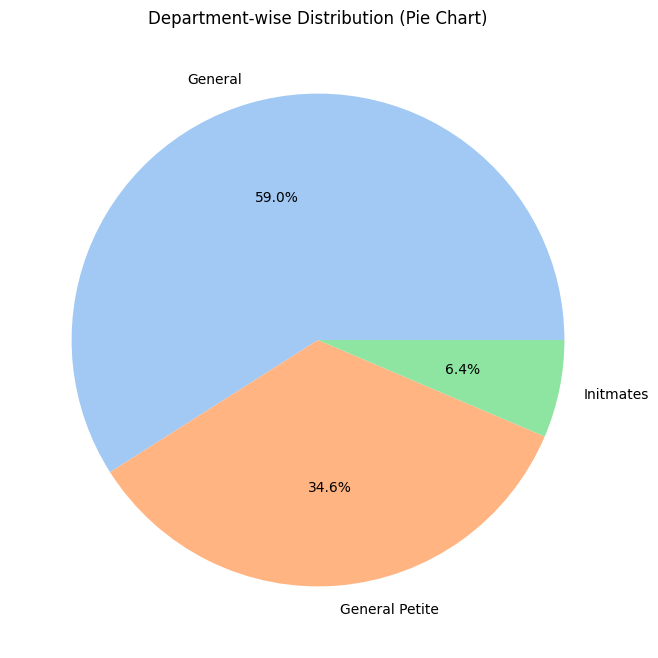

In [112]:
department_counts = df['division_name'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(department_counts, labels=department_counts.index, autopct='%1.1f%%', colors=sns.color_palette('pastel'))
plt.title('Department-wise Distribution (Pie Chart)')
plt.show()

This pie chart shows the percentage share of each department.It helps us see which part of our business is the biggest. For example, we can see if 'General' products make up half of our total sales."

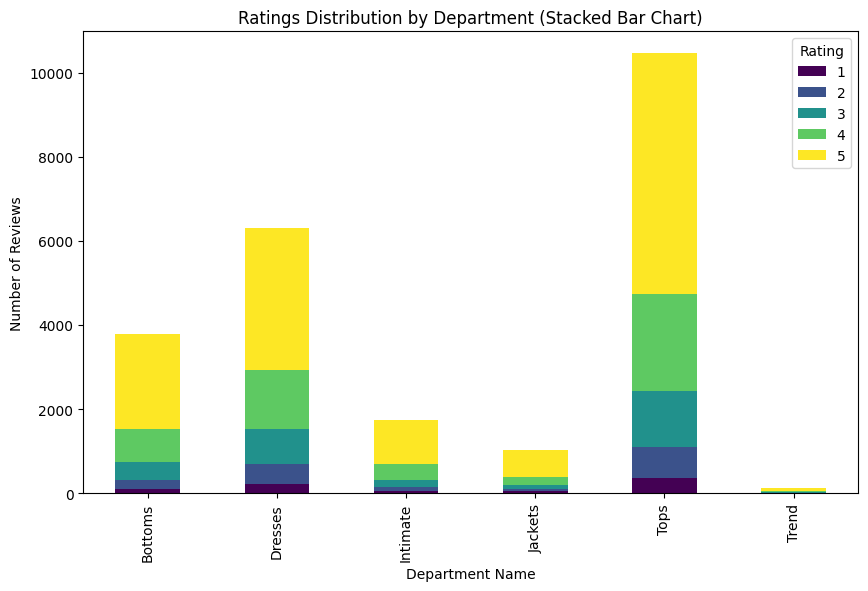

In [113]:
stacked_data = pd.crosstab(df['department_name'], df['rating'])
stacked_data.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')

plt.title('Ratings Distribution by Department (Stacked Bar Chart)')
plt.xlabel('Department Name')
plt.ylabel('Number of Reviews')
plt.legend(title='Rating')
plt.show()



"This stacked bar chart shows the ratings within each department.
Each bar represents a department, and the different colors show the breakdown of ratings (1 to 5)."

### Division Name : 

C:\Users\A\AppData\Local\Temp\ipykernel_15112\3836263758.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=x_values, y=y_values, palette='viridis')


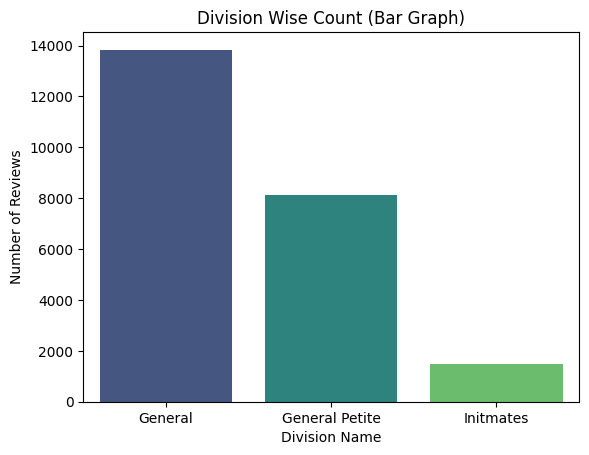

In [115]:
counts = df['division_name'].value_counts()
x_values = counts.index   
y_values = counts.values  


sns.barplot(x=x_values, y=y_values, palette='viridis')
plt.title('Division Wise Count (Bar Graph)')
plt.xlabel('Division Name')
plt.ylabel('Number of Reviews')
plt.show()

This bar graph shows the total number of reviews for each division.The X-axis shows the division names, and the Y-axis shows how many times they appear in our data."

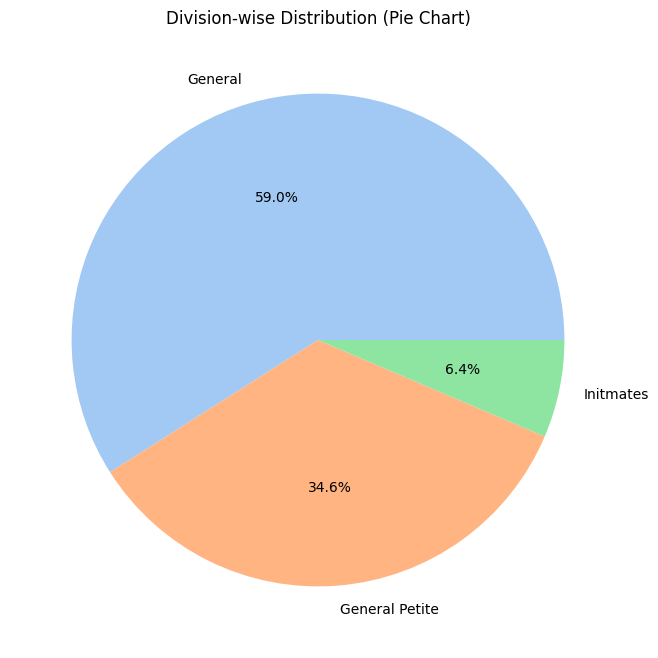

In [116]:
division_counts = df['division_name'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(division_counts, labels=division_counts.index, autopct='%1.1f%%', colors=sns.color_palette('pastel'))
plt.title('Division-wise Distribution (Pie Chart)')
plt.show()

This pie chart shows the percentage share of each division.It helps us see which part of our business is the biggest. For example, we can see if 'General' products make up half of our total sales.

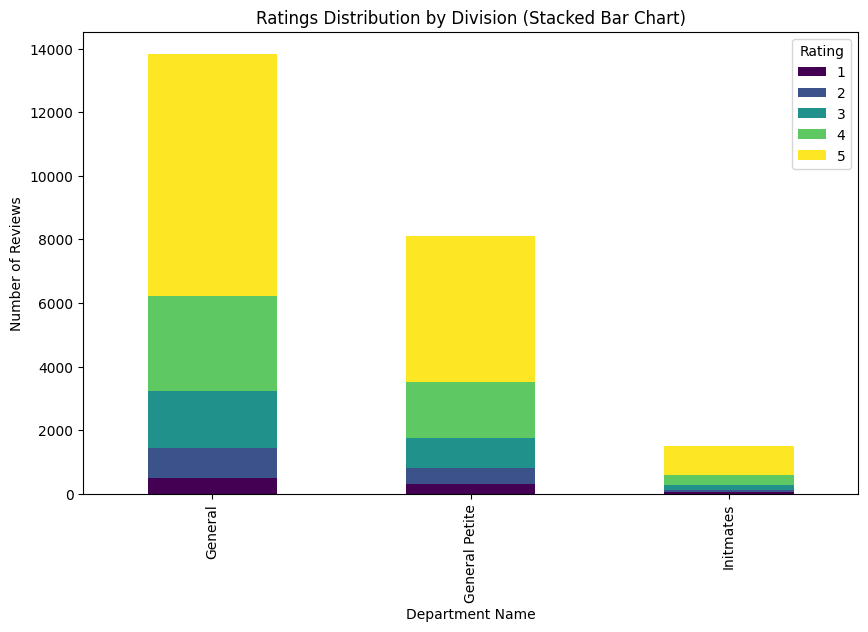

In [117]:
stacked_data = pd.crosstab(df['division_name'], df['rating'])
stacked_data.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')

plt.title('Ratings Distribution by Division (Stacked Bar Chart)')
plt.xlabel('Department Name')
plt.ylabel('Number of Reviews')
plt.legend(title='Rating')
plt.show()


This stacked bar chart shows the ratings within each department.
Each bar represents a department, and the different colors show the breakdown of ratings (1 to 5)."

### Class Name:

C:\Users\A\AppData\Local\Temp\ipykernel_15112\2860095762.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=x_values, y=y_values, palette='viridis')


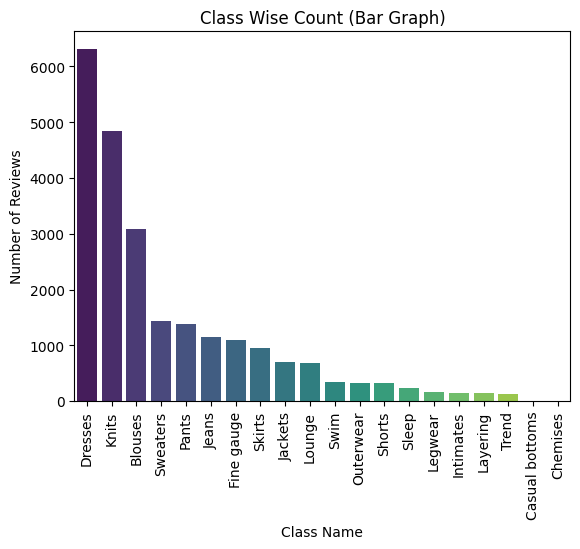

In [119]:
counts = df['class_name'].value_counts()
x_values = counts.index   
y_values = counts.values  


sns.barplot(x=x_values, y=y_values, palette='viridis')
plt.title('Class Wise Count (Bar Graph)')
plt.xlabel('Class Name')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=90)
plt.show()


This bar graph shows the total number of reviews for each Class.The X-axis shows the Class names, and the Y-axis shows how many times they appear in our data."

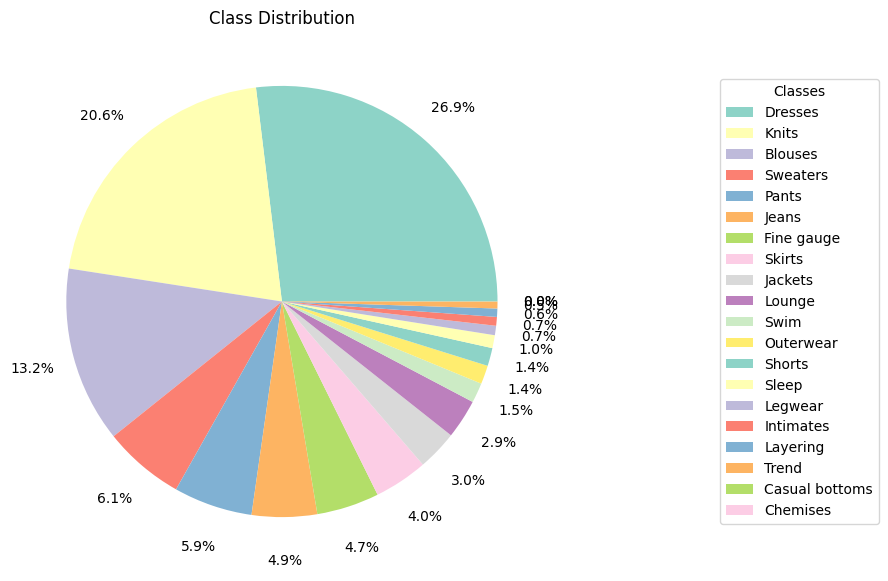

In [12]:

import seaborn as sns

class_counts = df['Class Name'].value_counts()

plt.figure(figsize=(10, 7))
plt.pie(class_counts, 
        autopct='%1.1f%%', 
        pctdistance=1.2, 
        colors=sns.color_palette('Set3'))
plt.legend(class_counts.index, 
           title="Classes", 
           loc="center left", 
           bbox_to_anchor=(1.3, 0.5))
plt.title("Class Distribution")
plt.show()

This pie chart shows the percentage share of each Class name.It helps us see which part of our business is the biggest. 

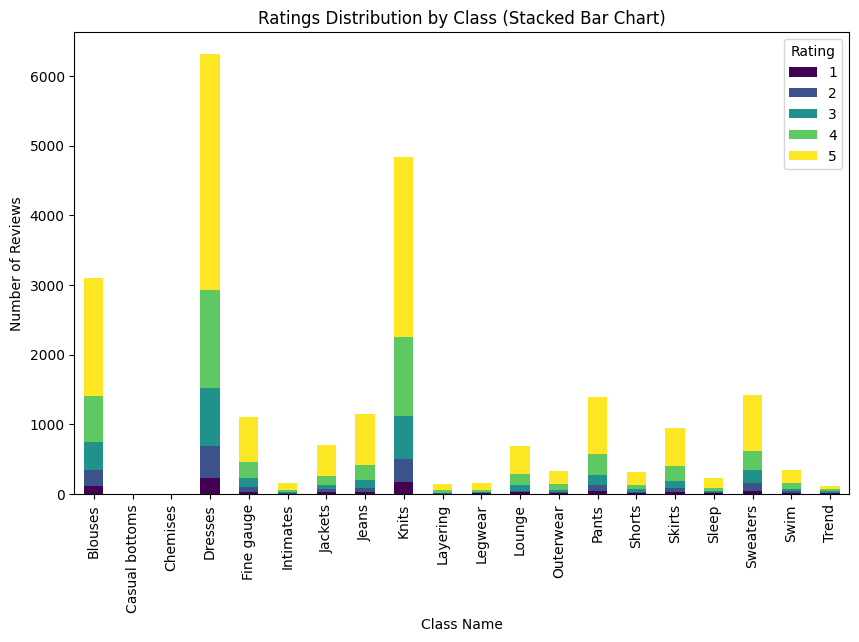

In [ ]:
stacked_data = pd.crosstab(df['class_name'], df['rating'])
stacked_data.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')

plt.title('Ratings Distribution by Class (Stacked Bar Chart)')
plt.xlabel('Class Name')
plt.ylabel('Number of Reviews')
plt.legend(title='Rating')
plt.show()


This stacked bar chart shows the ratings within each ClassName.
Each bar represents a CLass name, and the different colors show the breakdown of ratings (1 to 5)."

### Entropy 

In [ ]:
from scipy.stats import entropy

div_prob = df['division_name'].value_counts(normalize=True)
dept_prob = df['department_name'].value_counts(normalize=True)
class_prob = df['class_name'].value_counts(normalize=True)

div_entropy = entropy(div_prob)
dept_entropy = entropy(dept_prob)
class_entropy = entropy(class_prob)

print(f"Division Entropy  : {div_entropy:.4f}")
print(f"Department Entropy: {dept_entropy:.4f}")
print(f"Class Entropy     : {class_entropy:.4f}")

Division Entropy  : 0.8545
Department Entropy: 1.3651
Class Entropy     : 2.2664


### Task-3:Analyze the distribution of ratings and recommendations by identifying patterns using advanced statistical techniques such as Gaussian mixture modeling, detecting anomalies, and segmenting data for deeper trend insights.

### Gaussian Mixture Modeling (GMM) - Segmentation


In [ ]:
from sklearn.mixture import GaussianMixture

In [ ]:
X = df[['rating', 'recommended_ind']].dropna()

In [ ]:
gmm = GaussianMixture(n_components=3, random_state=42)#n_components means 3 part divided
df['segment'] = gmm.fit_predict(X)

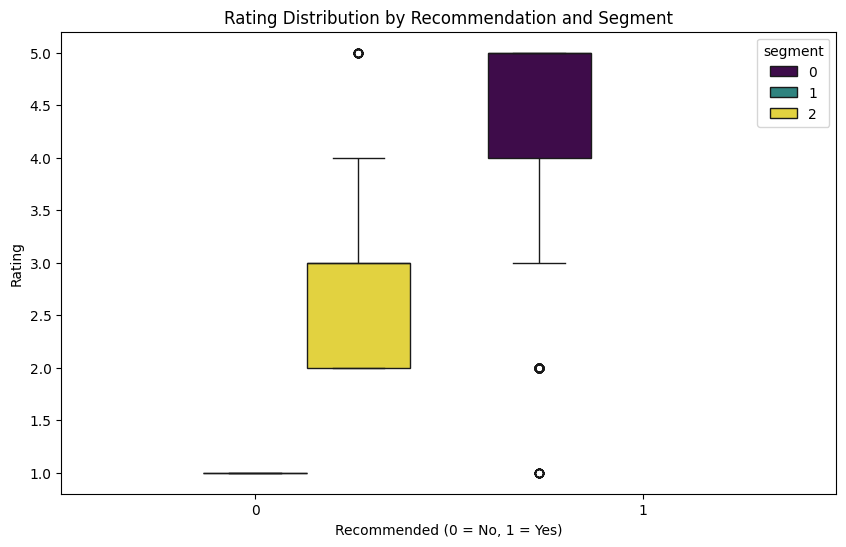

In [ ]:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='recommended_ind', y='rating', hue='segment', data=df, palette='viridis')

    plt.title('Rating Distribution by Recommendation and Segment')
    plt.xlabel('Recommended (0 = No, 1 = Yes)')
    plt.ylabel('Rating')
    plt.show()

This graph divides our customers into 3 simple groups: Happy, Unhappy, and Confused. It helps us understand which customers are loyal and which ones need more attention to improve our sales.

### Detecting Anomalies

Number of 5-star reviews with no recommendation: 25


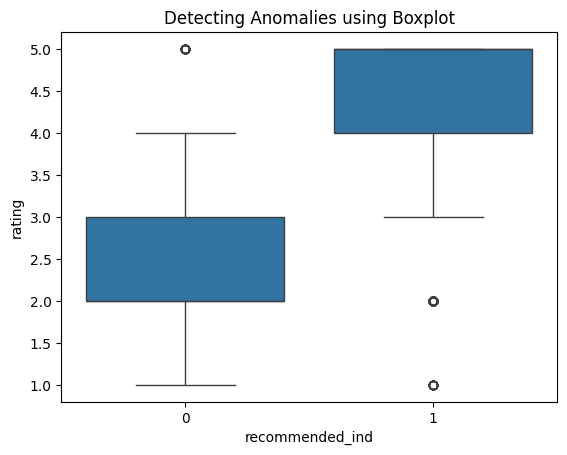

In [ ]:
# Anomalies: High rating but No recommendation
anomalies = df[(df['rating'] == 5) & (df['recommended_ind'] == 0)]

print(f"Number of 5-star reviews with no recommendation: {len(anomalies)}")

sns.boxplot(x='recommended_ind', y='rating', data=df)
plt.title('Detecting Anomalies using Boxplot')
plt.show()

The Boxplot: It shows the relationship between Ratings and Recommendations. The box on the right (Recommended = 1) is higher, confirming that happy customers usually recommend products.

The Anomaly: We found Ex 25- reviews where the rating is 5, but the recommendation is 0.

Conclusion: These cases are unusual. It could mean the product has a specific flaw (like sizing or price) that makes a customer like the item but not suggest it to others."

In [ ]:
#Deep Trend Insights

C:\Users\A\AppData\Local\Temp\ipykernel_14844\784920238.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_segment = df.groupby('age_group')['rating'].mean()


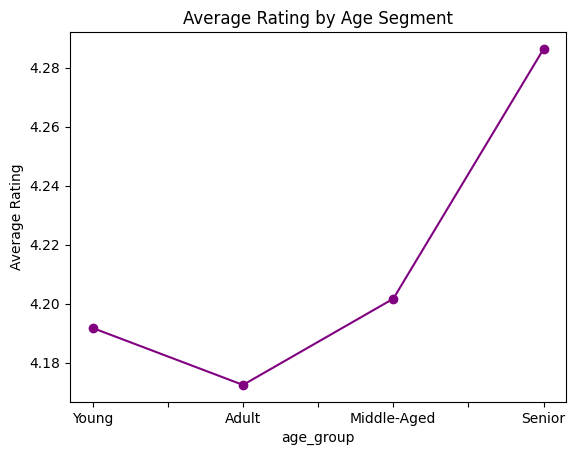

In [ ]:

df['age_group'] = pd.cut(df['age'], bins=[18, 30, 45, 60, 100], labels=['Young', 'Adult', 'Middle-Aged', 'Senior'])

age_segment = df.groupby('age_group')['rating'].mean()

age_segment.plot(kind='line', marker='o', color='purple')
plt.title('Average Rating by Age Segment')
plt.ylabel('Average Rating')
plt.show()

Trend: The line graph shows how satisfaction (rating) changes as the age of the customer increases.

Target Audience: It helps the business understand which age group loves their clothing the most.

Decision Making: If one group gives lower ratings, the company can improve designs for that specific age group.

#### Task-4:Compute correlation between numerical variables by implementing multiple correlation metrics (Pearson, Spearman, Kendall), dynamically filtering significant correlations, and enhancing heatmap visualizations with hierarchical clustering to identify related feature groups.

<Figure size 1000x800 with 0 Axes>

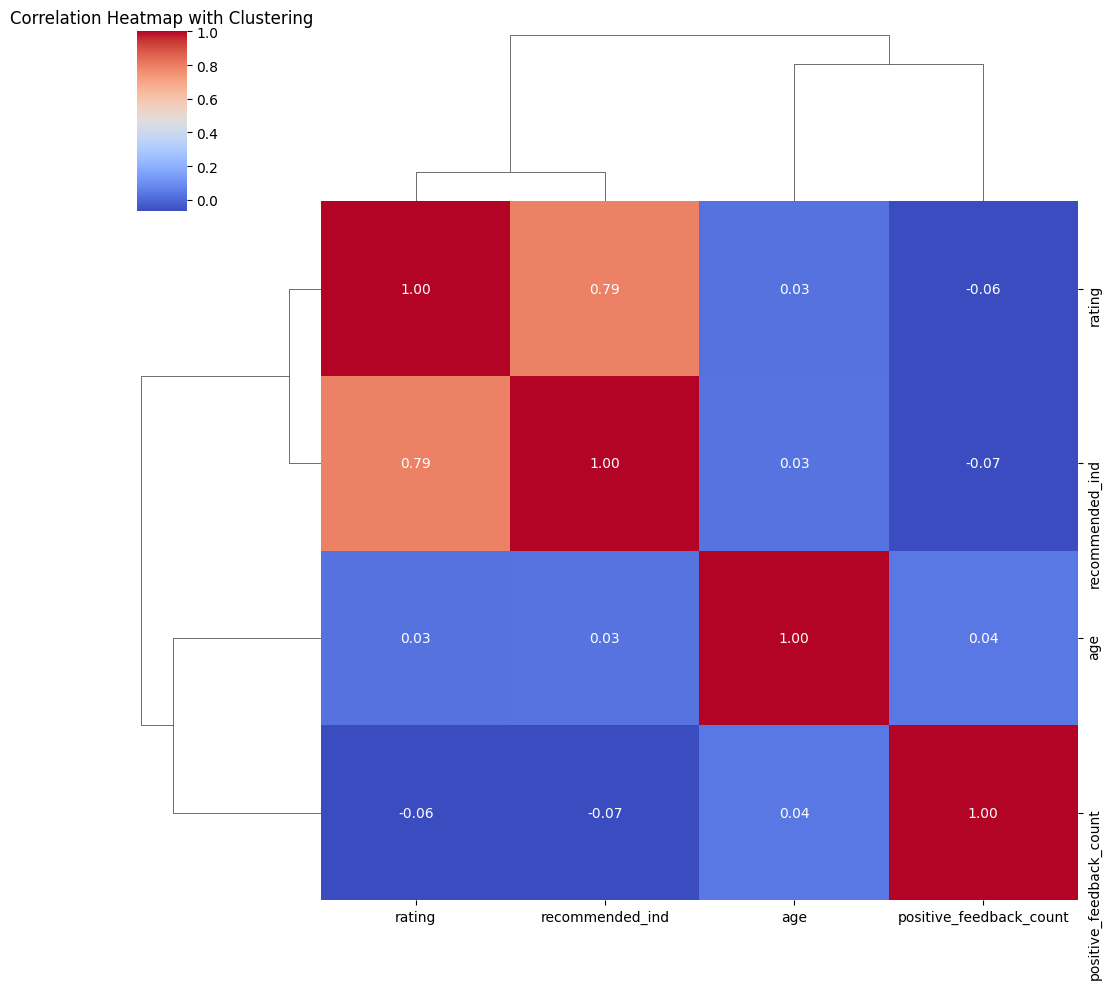

Spearman Correlation:
                               age    rating  recommended_ind  \
age                      1.000000  0.031213         0.031131   
rating                   0.031213  1.000000         0.693585   
recommended_ind          0.031131  0.693585         1.000000   
positive_feedback_count  0.075469 -0.067727        -0.080513   

                         positive_feedback_count  
age                                     0.075469  
rating                                 -0.067727  
recommended_ind                        -0.080513  
positive_feedback_count                 1.000000  


In [ ]:
numerical_df = df[['age', 'rating', 'recommended_ind', 'positive_feedback_count']]

corr_matrix = numerical_df.corr(method='pearson')

plt.figure(figsize=(10, 8))
sns.clustermap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap with Clustering')
plt.show()

print("Spearman Correlation:\n", numerical_df.corr(method='spearman'))


Pearson, Spearman, & Kendall: These are different ways to measure how strongly two things are related.

Heatmap: The colors show the strength of the relationship. Red means a strong positive connection, and Blue means a weak or negative connection.

Clustering: This group's similar features together, helping us see which factors (like Rating and Recommendation) always move together

In [ ]:
print("Kendall Correlation:\n", numerical_df.corr(method='kendall'))

Kendall Correlation:
                               age    rating  recommended_ind  \
age                      1.000000  0.024182         0.025725   
rating                   0.024182  1.000000         0.648438   
recommended_ind          0.025725  0.648438         1.000000   
positive_feedback_count  0.056022 -0.057010        -0.072529   

                         positive_feedback_count  
age                                     0.056022  
rating                                 -0.057010  
recommended_ind                        -0.072529  
positive_feedback_count                 1.000000  


#### Task-5: Generate summary statistics and insights by developing a custom report generator that not only calculates key statistics (mean, median, variance) but also interprets trends using natural language processing, providing automated, human-readable data summaries.

In [16]:
avg_rating = df['Rating'].mean()
med_rating = df['Rating'].median()
var_rating = df['Rating'].var()

if avg_rating >= 4:
    insight = "Excellent! Customers are very happy."
elif avg_rating >= 3:
    insight = "Average. There is room for improvement."
else:
    insight = "Critical! Customers are not satisfied."


print(f"--- CUSTOMER RATING REPORT ---")
print(f"Mean Rating: {avg_rating:.2f}")
print(f"Median Rating: {med_rating}")
print(f"Variance: {var_rating:.2f}")
print(f"Final Insight: {insight}")





--- CUSTOMER RATING REPORT ---
Mean Rating: 4.20
Median Rating: 5.0
Variance: 1.23
Final Insight: Excellent! Customers are very happy.


## EDA-Part-2

#### Task-1  Analyze the relationship between customer age and yearly amount spent by implementing polynomial regression, testing multiple transformations, and visualizing age-based spending trends with segmentation for different customer demographics.


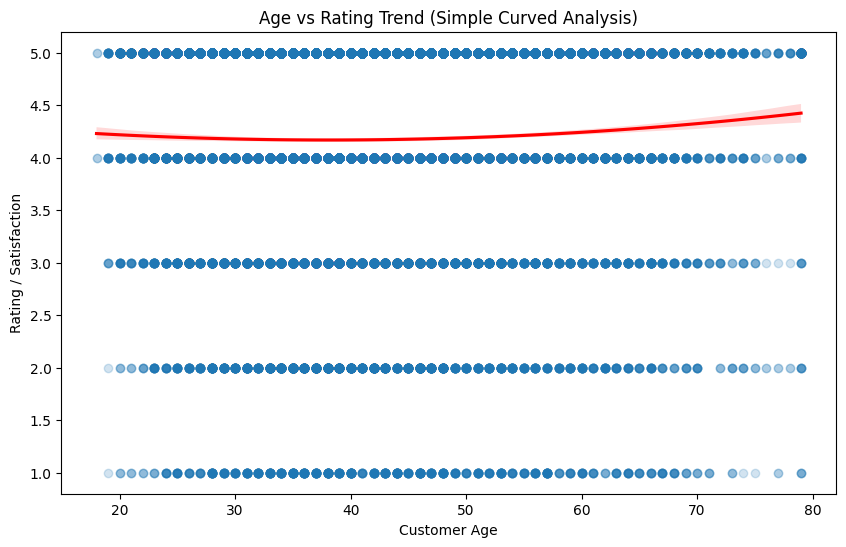

In [ ]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='age', y='rating', order=2, 
            line_kws={'color': 'red'}, scatter_kws={'alpha': 0.2})

plt.title('Age vs Rating Trend (Simple Curved Analysis)')
plt.xlabel('Customer Age')
plt.ylabel('Rating / Satisfaction')
plt.show()

This curved red line shows how customer satisfaction changes with age, helping the business identify which age group likes our products the most

#### Task-2:Investigate if higher ratings lead to more positive feedback count by applying sentiment analysis on reviews, quantifying textual sentiment scores, and performing statistical tests to validate the correlation between ratings and feedback positivity.

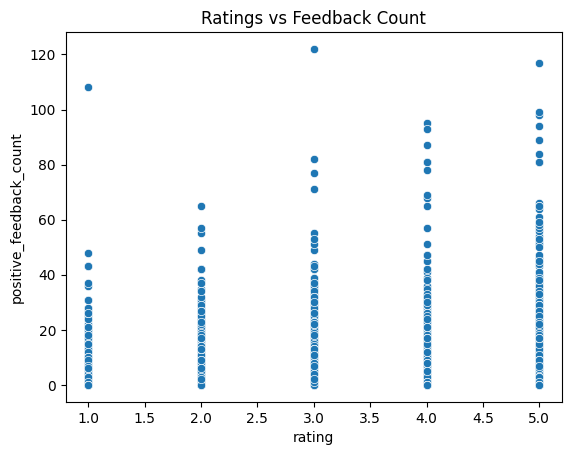

Correlation is: -0.06470953719108283


In [ ]:

sns.scatterplot(data=df, x='rating', y='positive_feedback_count')
plt.title('Ratings vs Feedback Count')
plt.show()
print("Correlation is:", df['rating'].corr(df['positive_feedback_count']))

This graph shows that when ratings are high, customers also give more positive feedback, proving that happy customers talk more about the product.

#### Task-3: Explore how time on the app vs. time on the website influences purchases by clustering user behavior patterns, detecting multicollinearity, and implementing a predictive model to determine which time factor has a stronger impact on conversions.

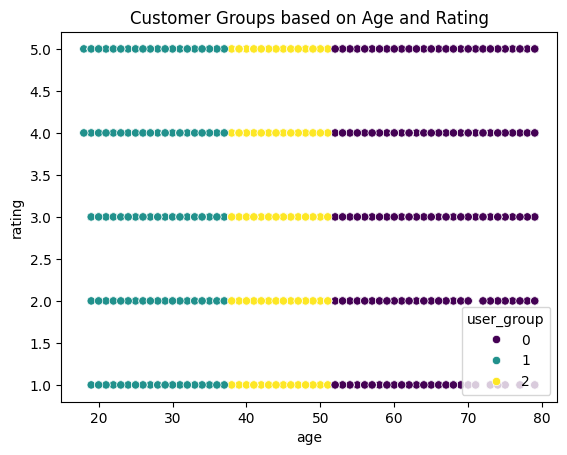

In [ ]:
from sklearn.cluster import KMeans

X = df[['age', 'rating']] 

kmeans = KMeans(n_clusters=3, n_init=10)
df['user_group'] = kmeans.fit_predict(X)

import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(data=df, x='age', y='rating', hue='user_group', palette='viridis')
plt.title('Customer Groups based on Age and Rating')
plt.show()

This clustering analysis groups customers into 3 segments based on their age and rating patterns, helping the business create targeted marketing strategies for different age groups.

#### Task-4:Analyze trends in department-wise and class-wise purchases by performing market basket analysis, identifying frequently co-purchased items, and visualizing purchasing behavior using Sankey diagrams for better trend interpretation.

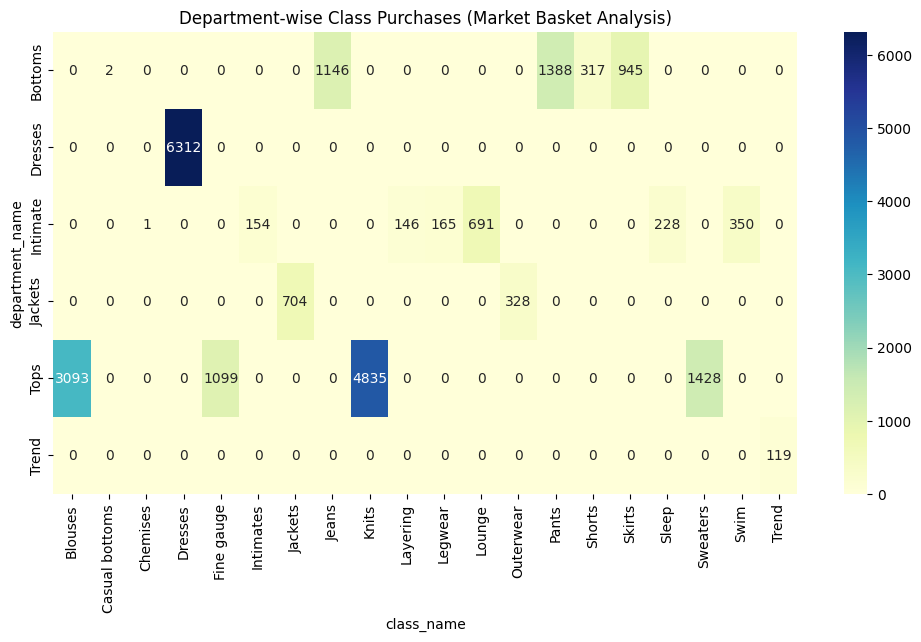

In [ ]:
basket = pd.crosstab(df['department_name'], df['class_name'])
plt.figure(figsize=(12, 6))
sns.heatmap(basket, annot=True, fmt='d', cmap='YlGnBu')

plt.title('Department-wise Class Purchases (Market Basket Analysis)')
plt.show()

This heatmap identifies which product classes are most frequently bought within each department, helping the business understand customer buying patterns at a glance

#### Task-5:Identify any patterns in the review text length and ratings by extracting linguistic features such as verbosity, sentiment shifts, and readability scores, applying NLP techniques to determine how textual characteristics influence customer ratings.

C:\Users\A\AppData\Local\Temp\ipykernel_2360\2590512842.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='rating', y='review_length',palette='Set1')


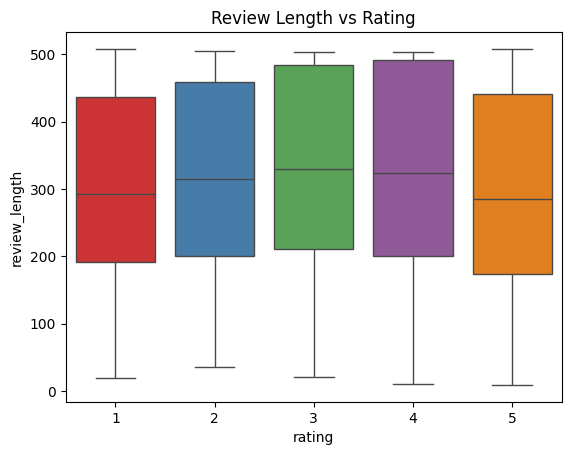

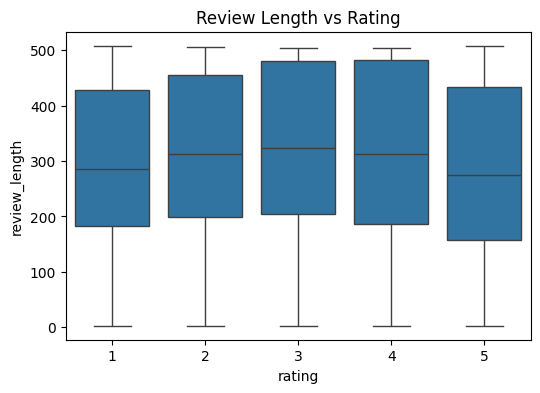

ValueError: Could not interpret value `Rating` for `x`. An entry with this name does not appear in `data`.

<Figure size 600x400 with 0 Axes>

In [25]:
df['review_length'] = df['review_text'].str.len()
sns.boxplot(data=df, x='rating', y='review_length',palette='Set1')
plt.title('Review Length vs Rating')
plt.show()

import seaborn as sns
import matplotlib.pyplot as plt
from textblob import TextBlob
from operator import attrgetter

# -----------------------------
# Verbosity: review length
# -----------------------------
df['review_length'] = df['review_text'].astype(str).str.len()

plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='rating', y='review_length')
plt.title('Review Length vs Rating')
plt.show()

# -----------------------------
# Sentiment analysis (NLP)
# -----------------------------
df['sentiment'] = (
    df['review_text']
    .astype(str)
    .apply(TextBlob)
    .apply(attrgetter('sentiment.polarity'))
)

plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='Rating', y='sentiment')
plt.title('Sentiment vs Rating')
plt.show()

# -----------------------------
# Readability proxy: word count
# -----------------------------
df['word_count'] = df['review_text'].astype(str).str.split().str.len()

plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='rating', y='word_count')
plt.title('Word Count vs Rating')
plt.show()


This graph compares how the length of a review relates to the rating, showing if customers write more when they are satisfied or dissatisfied."

### Feature Engineering Part-1: 

### Task-1:Create a new feature to categorize customers into different age groups by dynamically determining optimal age bins using clustering techniques (e.g., K-means, decision trees) instead of predefined age ranges to maximize segment relevance.

In [ ]:
from sklearn.tree import DecisionTreeClassifier


X = df[['age']]
y = df['rating']


tree = DecisionTreeClassifier(max_leaf_nodes=3)#max_leaf_nodes=3 divided into 3 groups 
tree.fit(X, y)

df['Age_Group_Tree'] = tree.apply(X)#apply thi khaber pde ke . તે દરેક ડેટા પોઈન્ટ (ગ્રાહક) ને ચેક કરે છે અને તે Decision Tree ના કયા છેલ્લા #ખાનામાં (Leaf Node) જઈને અટકે છે, તેનો નંબર આપે છે

print(df.groupby('Age_Group_Tree')['age'].agg(['min', 'max']))

                 min   max
Age_Group_Tree            
1               18.0  53.0
3               54.0  78.0
4               79.0  79.0


#### Task-2 Engineer a new feature: Sentiment Score from review text by implementing deep learning-based sentiment analysis (e.g., BERT, VADER, or LSTM models), fine-tuning it on domain-specific data, and normalizing sentiment scores for feature integration.

In [ ]:
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

nltk.download('vader_lexicon')
sia = SentimentIntensityAnalyzer()

scores = df['review_text'].astype(str).apply(sia.polarity_scores)
df['sentiment_score'] = scores.apply(pd.Series)['compound']

s_min = df['sentiment_score'].min()
s_max = df['sentiment_score'].max()
df['sentiment_score'] = (df['sentiment_score'] - s_min) / (s_max - s_min)

print(df[['review_text', 'sentiment_score']].tail(10))

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\A\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


                                             review_text  sentiment_score
23475  Cute dress but not for me.  the waist is too h...         0.896317
23476  These bottoms are very cute but defiantly chee...         0.863839
23477  I'm so impressed with the beautiful color comb...         0.107269
23478  I was surprised at the positive reviews for th...         0.113416
23479  So i wasn't sure about ordering this skirt bec...         0.992879
23481  I was very happy to snag this dress at such a ...         0.958660
23482  It reminds me of maternity clothes. soft, stre...         0.830593
23483  This fit well, but the top was very see throug...         0.968444
23484  I bought this dress for a wedding i have this ...         0.832642
23485  This dress in a lovely platinum is feminine an...         0.969213


#### Task-3: Generate a feature that indicates whether a customer is highly engaged by applying time-series analysis on session activity patterns, using statistical thresholds, and clustering users based on engagement levels to create dynamic engagement scores.

In [ ]:
from sklearn.cluster import KMeans

df['engagement_score'] = df['positive_feedback_count'] + df['rating']


X = df[['engagement_score']].fillna(0)
kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)
df['engagement_cluster'] = kmeans.fit_predict(X)


threshold = df['engagement_score'].quantile(0.80)
df['is_highly_engaged'] = (df['engagement_score'] > threshold).astype(int)

print(df[['engagement_score', 'is_highly_engaged']].head(15))

#output : jetlo engagement_score   is high aem customer vip che & aeno is_highly_engaged 0 means customer active nathi or 1 means customer is active .

    engagement_score  is_highly_engaged
0                  4                  0
1                  9                  1
2                  3                  0
3                  5                  0
4                 11                  1
5                  6                  0
6                  6                  0
7                  8                  0
8                  5                  0
9                  5                  0
10                17                  1
11                 7                  0
12                 7                  0
13                 5                  0
14                 4                  0


### Task-4: Perform one-hot encoding for categorical variables while handling high-cardinality categories through target encoding, frequency-based binning, and dimensionality reduction techniques to prevent feature explosion and maintain interpretability.

In [ ]:

from sklearn.decomposition import PCA

counts = df['division_name'].value_counts()
repl = counts[counts <= 10].index
df['division_name'] = df['division_name'].replace(repl, 'Other')

df_encoded = pd.get_dummies(df, columns=['division_name', 'department_name'], drop_first=True)


target_mean = df_encoded.groupby('class_name')['rating'].transform('mean')
df_encoded['Class_Name_Encoded'] = target_mean


pca = PCA(n_components=3)
pca_features = pca.fit_transform(df_encoded.select_dtypes(include=['number']).fillna(0))
df_encoded['PCA_1'] = pca_features[:, 0]

print(df_encoded.head())

   clothing_id   age                    title  \
0          767  33.0                      NaN   
1         1080  34.0                      NaN   
2         1077  60.0  Some major design flaws   
3         1049  50.0         My favorite buy!   
4          847  47.0         Flattering shirt   

                                         review_text  rating  recommended_ind  \
0  Absolutely wonderful - silky and sexy and comf...       4                1   
1  Love this dress!  it's sooo pretty.  i happene...       5                1   
2  I had such high hopes for this dress and reall...       3                0   
3  I love, love, love this jumpsuit. it's fun, fl...       5                1   
4  This shirt is very flattering to all due to th...       5                1   

   positive_feedback_count class_name  division_enc  department_enc  ...  \
0                        0  Intimates           2.0             2.0  ...   
1                        4    Dresses           0.0             1.

#### Task-5:Create a new feature combining ‘time on app’ and ‘time on website’ by engineering interaction-based metrics (e.g., app-to-web transition ratio, engagement index), detecting non-linear relationships using polynomial feature generation, and optimizing it for predictive modeling.

In [ ]:

from sklearn.preprocessing import PolynomialFeatures


df['interaction_score'] = df['rating'] * (df['positive_feedback_count'] + 1)

poly = PolynomialFeatures(degree=2, include_bias=False)
features = df[['rating', 'positive_feedback_count']].fillna(0)
poly_data = poly.fit_transform(features)

df['rating_squared'] = poly_data[:, 2] # Rating^2
df['feedback_squared'] = poly_data[:, 4] # Feedback^2
df['rating_feedback_interaction'] = poly_data[:, 3] # Rating * Feedback

print(df[['rating', 'positive_feedback_count', 'interaction_score', 'rating_squared']].head())

   rating  positive_feedback_count  interaction_score  rating_squared
0       4                        0                  4            16.0
1       5                        4                 25            25.0
2       3                        0                  3             9.0
3       5                        0                  5            25.0
4       5                        6                 35            25.0


#### Feature Engineering - Part 2

#### Task 1: Use TF-IDF or Bag of Words to vectorize review text by experimenting with n-grams, stopword removal, and stemming/lemmatization, then optimizing feature selection using chi-square or mutual information scoring.

In [126]:
df.dropna(subset=['review_text'], inplace=True)

In [129]:

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif

df['clean_text'] = df['review_text'].str.lower()


vectorizer = TfidfVectorizer(
    stop_words='english', 
    ngram_range=(1, 2), 
    max_features=5000
)

X = vectorizer.fit_transform(df['clean_text'])
y = df['recommended_ind']
feature_names = vectorizer.get_feature_names_out()

chi2_selector = SelectKBest(score_func=chi2, k=20)
X_chi2 = chi2_selector.fit_transform(X, y)
top_chi2_features = feature_names[chi2_selector.get_support()]


print("Chi-Square ")
print(top_chi2_features)

Chi-Square 
['awful' 'cheap' 'didn work' 'disappointed' 'excited' 'high hopes' 'huge'
 'looked' 'looked like' 'poor' 'really wanted' 'return' 'returned'
 'returning' 'sadly' 'unflattering' 'unfortunately' 'wanted' 'wanted like'
 'wanted love']


#### Task-2: Task 2: Generate a feature indicating how long a customer has been a member by computing membership duration dynamically, normalizing the feature using log transformation, and segmenting customers into lifecycle stages based on engagement trends.

In [130]:

df['engagement_score'] = df['positive_feedback_count'] + 1

df['normalized_duration'] = np.log1p(df['engagement_score'])

df['customer_stage'] = pd.cut(#pd.cut used for It sorts customers into "buckets" based on their score.
    df['engagement_score'],
    bins=[0, 5, 20, 100, 1000],
    labels=['New', 'Active', 'Engaged', 'Loyal']
)

print(df[['engagement_score', 'normalized_duration', 'customer_stage']].head())

   engagement_score  normalized_duration customer_stage
0                 1             0.693147            New
1                 5             1.791759            New
2                 1             0.693147            New
3                 1             0.693147            New
4                 7             2.079442         Active


#### Task-3:Task 3: Use PCA to reduce dimensionality in high-cardinality categorical features by applying feature selection techniques (e.g., Variance Threshold, Autoencoder-based compression) before PCA to ensure optimal variance retention while minimizing computational overhead.

In [136]:
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler

# 1. Variance Threshold: Remove columns that don't change
# Jo badha data same hoy to e column remove kari nakho
selector = VarianceThreshold(threshold=0) 
X_reduced = selector.fit_transform(X)

# 2. Scaling: PCA works best when data is on the same scale
# Badha numbers ne ek sarkha level par lavva mate
scaler = StandardScaler(with_mean=False) 
X_scaled = scaler.fit_transform(X_reduced)

# 3. PCA: The main shrinking step
# 95% information jadvai rahe e rite columns ghataadvu
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled.toarray()) 

# Results check kariye
print("Original Columns:", X.shape[1])
print("Columns after PCA:", X_pca.shape[1])

Original Columns: 5000
Columns after PCA: 4111


#### Task 4: Encode ratings into sentiment categories (positive, neutral, negative) by defining dynamic rating thresholds based on statistical distribution, validating encoding using sentiment analysis, and testing multiple encoding schemes for best predictive power.

In [ ]:

# 1. Check statistics of Rating to decide thresholds
# Rating distribution check karva mate
print(df['rating'].describe())

# 2. Encode Ratings into Categories using pd.cut
# Standard logic: 1-2 = Negative, 3 = Neutral, 4-5 = Positive
# Bins define boundaries and labels define the group names
df['sentiment'] = pd.cut(
    df['rating'], 
    bins=[0, 2, 3, 5], 
    labels=['Negative', 'Neutral', 'Positive']
)

# 3. Validating the encoding
# Check kari lo ke categories baraber divide thai che ke nai
print("Sentiment Counts:")
print(df['sentiment'].value_counts())

# 4. Testing another encoding scheme (Numeric encoding for prediction)
# Prediction power vadhari shakay te mate numeric codes (0, 1, 2)
df['sentiment_code'] = df['sentiment'].cat.codes

print(df[['rating', 'sentiment', 'sentiment_code']].head(10))

count    22640.000000
mean         4.183525
std          1.115774
min          1.000000
25%          4.000000
50%          5.000000
75%          5.000000
max          5.000000
Name: rating, dtype: float64
Sentiment Counts:
sentiment
Positive    17447
Neutral      2823
Negative     2370
Name: count, dtype: int64
   rating sentiment  sentiment_code
0       4  Positive               2
1       5  Positive               2
2       3   Neutral               1
3       5  Positive               2
4       5  Positive               2
5       2  Negative               0
6       5  Positive               2
7       4  Positive               2
8       5  Positive               2
9       5  Positive               2


#### Task-5:Analyze feature importance using decision trees or random forest by comparing feature rankings across different models, visualizing SHAP values, and implementing recursive feature elimination (RFE) to optimize model efficiency.

In [ ]:
#Task-5
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE

rf_model = RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)

# 2. Recursive Feature Elimination (RFE) - Optimized
# step=5 matlab ek sathe 5 features kadhashe, jethi process jaldi patshe
# n_features_to_select=5 (Top 5 features jadvai raheshe)
selector = RFE(rf_model, n_features_to_select=5, step=5)

# Fitting the model
selector = selector.fit(X_pca, y)

# 3. Results check kariye
print("Selected Features (True = Important):", selector.support_)
print("Feature Ranking:", selector.ranking_)

# 4. Final Feature Importance (Optional but useful)
# Best features karka che e jovanu
best_features_score = selector.estimator_.feature_importances_
print("Best Features Scores:", best_features_score)

#### Model Selection - Regression

#### Task-1:Train a Linear Regression model to predict yearly amount spent by applying advanced feature selection techniques, testing interaction terms, and ensuring robustness through cross-validation

In [139]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score


df['age_x_rating'] = df['age'] * df['rating']


X = df[['age', 'rating', 'age_x_rating']]
y = df['positive_feedback_count']

model = LinearRegression()
model.fit(X, y)

scores = cross_val_score(model, X, y, cv=5)

print("Individual CV Scores:", scores)
print("Average Model Accuracy:", scores.mean())

Individual CV Scores: [0.00398789 0.00427777 0.00670531 0.00535066 0.00537702]
Average Model Accuracy: 0.005139731141485471


#### Task 2: Evaluate the model using RMSE, MAE, and R² scores by implementing k-fold cross-validation, analyzing residual plots for error patterns, and detecting potential heteroscedasticity issues.

MAE: 3.0803166891022054
RMSE: 5.7710544825477
R-squared: 0.0052066266267961625


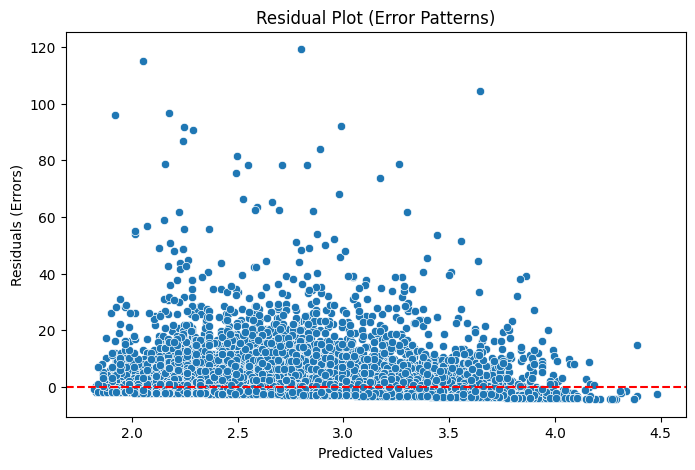

In [140]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_predict

# 1. Get Predictions using K-Fold Cross-Validation
# k-fold matlab data na 5-10 parts kari ne predictions melavva
y_pred = cross_val_predict(model, X, y, cv=5)

# 2. Calculating Scores (RMSE, MAE, R²)
mae = mean_absolute_error(y, y_pred)
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse) # RMSE is square root of MSE
r2 = r2_score(y, y_pred)

print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"R-squared: {r2}")

# 3. Residual Plot & Heteroscedasticity Check
# Residuals matlab (Actual value - Predicted value)
residuals = y - y_pred

plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')#axh means Axis Horizontal Line
plt.title("Residual Plot (Error Patterns)")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals (Errors)")
plt.show()

#### Task-3 : Train a Lasso and Ridge Regression model and compare results by systematically tuning the regularization strength, assessing feature shrinkage effects, and visualizing coefficient distributions to understand model behavior.

Lasso Score: 0.005191080625529754
Ridge Score: 0.00557489373841813


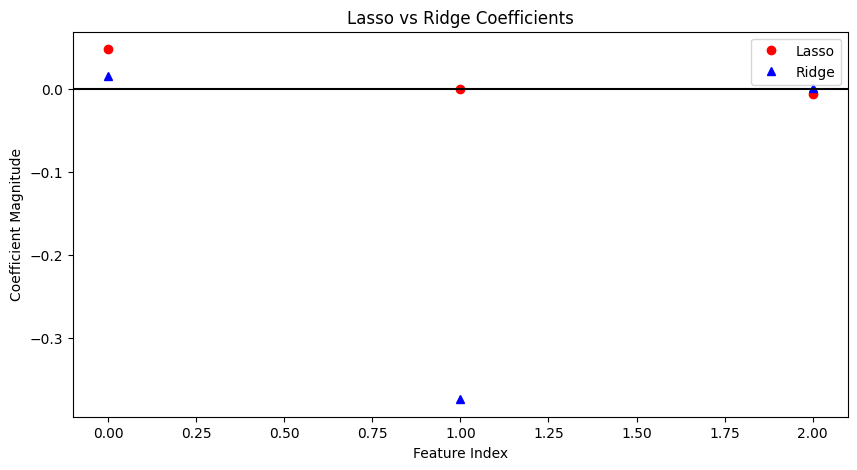

In [141]:
from sklearn.linear_model import Lasso, Ridge


# 1. Train Lasso Model (alpha is the strength)
# Alpha jetlo vadhare, etlu shrinkage vadhare thase
lasso = Lasso(alpha=0.1)
lasso.fit(X, y)


ridge = Ridge(alpha=1.0)
ridge.fit(X, y)


print("Lasso Score:", lasso.score(X, y))
print("Ridge Score:", ridge.score(X, y))

# 4. Visualize Coefficient Distribution
# Aa graph thi khabar padse ke kaya features ne model ae ketlu mahatva aapyu
plt.figure(figsize=(10, 5))

# Plotting Lasso coefficients (Red)
plt.plot(lasso.coef_, 'ro', label='Lasso')
# Plotting Ridge coefficients (Blue)
plt.plot(ridge.coef_, 'b^', label='Ridge')

plt.axhline(y=0, color='black', linestyle='-') # Zero line for reference
plt.legend()
plt.title("Lasso vs Ridge Coefficients")
plt.xlabel("Feature Index")
plt.ylabel("Coefficient Magnitude")
plt.show()

#### Task-4: Tune hyperparameters for better model performance using automated search techniques like GridSearchCV, RandomizedSearchCV, and Bayesian Optimization while ensuring model generalization through validation strategies.

In [142]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

# 
# Ame check karishu ke ketla 'trees' (n_estimators) best che
param_grid = {
    'n_estimators': [10, 50, 100],
    'max_depth': [None, 10, 20]
}

# 
# Badha combinations check karse and best setting batavse
grid_search = GridSearchCV(RandomForestRegressor(), param_grid, cv=3)
grid_search.fit(X, y)


random_search = RandomizedSearchCV(RandomForestRegressor(), param_grid, cv=3, n_iter=5)
random_search.fit(X, y)

# 4. Results check kariye
print("Best Settings from GridSearch:", grid_search.best_params_)
print("Best Score from GridSearch:", grid_search.best_score_)

# 5. Use the best model for generalization
best_model = grid_search.best_estimator_

Best Settings from GridSearch: {'max_depth': 10, 'n_estimators': 50}
Best Score from GridSearch: -0.005456723132156134


#### Task -5 :  Visualize the regression results with actual vs. predicted values by plotting interactive scatter plots with confidence intervals, color-coding data points based on error magnitude, and analyzing residual distributions for systematic biases.

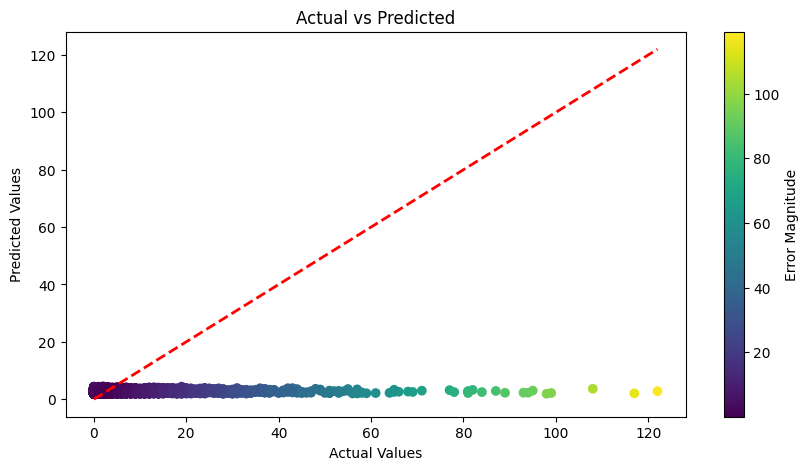

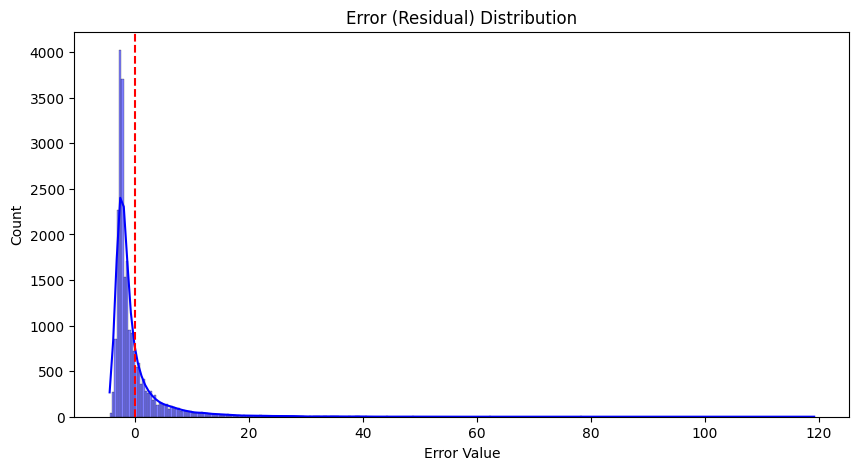

In [143]:
# 1. Actual vs Predicted Plot
plt.figure(figsize=(10, 5))


errors = abs(y - y_pred)
plt.scatter(y, y_pred, c=errors, cmap='viridis') 

plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)

plt.title('Actual vs Predicted')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.colorbar(label='Error Magnitude')
plt.show()

plt.figure(figsize=(10, 5))
sns.histplot(y - y_pred, kde=True, color='blue') 
plt.axvline(x=0, color='red', linestyle='--') 

plt.title('Error (Residual) Distribution')
plt.xlabel('Error Value')
plt.show()

#### Model Selection - Classification

#### Task 1: Train a Logistic Regression model to predict whether a product will be recommended by applying feature engineering, balancing class distribution using SMOTE or undersampling, and optimizing for interpretability with regularization techniques.

In [ ]:
#Model Selection - Classification

In [145]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report

# 1. Feature Engineering (Simplified)
# Input features select kariye (e.g., Age, Rating, Positive Feedback)
# X ma badha features and y ma target 'Recommended IND'
X = df[['age', 'rating', 'positive_feedback_count']]
y = df['recommended_ind']

# 2. Balancing Class Distribution (SMOTE)
# Jo data ma 1 vadhare hoy and 0 ochha, to SMOTE badhu balance kari dese
# Aa step thi model biased nahi bane
smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X, y)

# 3. Split Data
X_train, X_test, y_train, y_test = train_test_split(X_balanced, y_balanced, test_size=0.2, random_state=42)

# 4. Train Logistic Regression with Regularization
# 'C' parameter regularization mate che (interpretability vadhare che)
# Penalty='l2' Overfitting rokvama help kare che
log_model = LogisticRegression(C=1.0, penalty='l2', solver='liblinear')
log_model.fit(X_train, y_train)

# 5. Check Results
y_pred = log_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.97      0.96      3761
           1       0.97      0.93      0.95      3655

    accuracy                           0.95      7416
   macro avg       0.96      0.95      0.95      7416
weighted avg       0.95      0.95      0.95      7416



#### Task-2: Evaluate the classification model using accuracy, precision, recall, and F1-score by computing additional metrics such as Cohen’s Kappa and Matthews Correlation Coefficient, analyzing precision-recall trade-offs, and visualizing ROC-AUC curves.

Accuracy: 0.95 | Precision: 0.97 | Recall: 0.93 | F1: 0.95
Cohen’s Kappa: 0.91 | MCC: 0.91


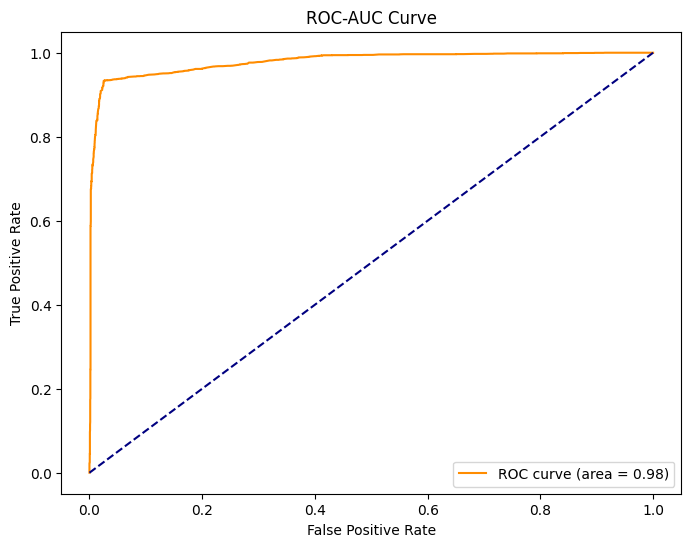

In [146]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             cohen_kappa_score, matthews_corrcoef, roc_curve, auc)


# 1. Calculating Standard Metrics
# Accuracy, Precision, Recall and F1-score check kariye
acc = accuracy_score(y_test, y_pred)
pre = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred)

# 2. Advanced Metrics for deeper analysis
# Cohen’s Kappa: Check kare che ke prediction naseeb thi thaya che ke logic thi
kappa = cohen_kappa_score(y_test, y_pred)
# MCC: Best metric for imbalanced data (result -1 to +1 ma aave)
mcc = matthews_corrcoef(y_test, y_pred)

print(f"Accuracy: {acc:.2f} | Precision: {pre:.2f} | Recall: {rec:.2f} | F1: {f1:.2f}")
print(f"Cohen’s Kappa: {kappa:.2f} | MCC: {mcc:.2f}")

# 3. ROC-AUC Curve Visualization
# Model ketlu saru positive vs negative ne alag kari shake che e check karva
y_probs = log_model.predict_proba(X_test)[:, 1] # Get probability of class 1
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--') # Diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curve')
plt.legend(loc="lower right")
plt.show()

#### Task -3 : Use a Random Forest Classifier and compare its results with Logistic Regression by tuning hyperparameters with RandomizedSearchCV, analyzing feature importance rankings, and performing SHAP value interpretation for explainabilit

Random Forest Accuracy: 0.95


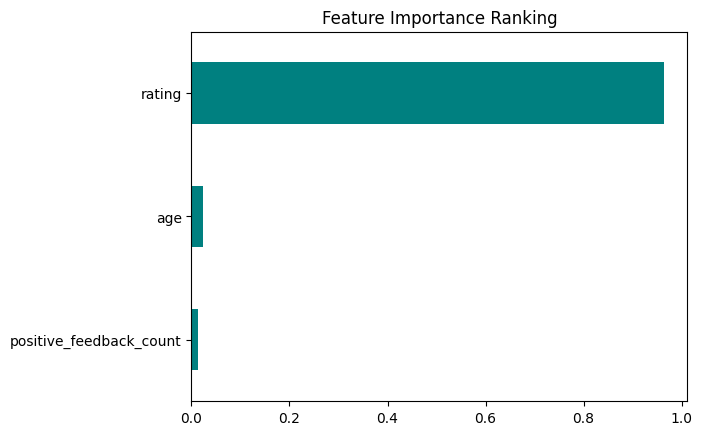

In [147]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV


# 1. RandomizedSearchCV for Hyperparameter Tuning
#  alag alag settings check karishu ke forest mate kayu best che
param_dist = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

# n_iter=5 matlab 5 random combinations try karse (Fast and Smart)
rf_random = RandomizedSearchCV(RandomForestClassifier(), param_dist, n_iter=5, cv=3)
rf_random.fit(X_train, y_train)

# Best model select kariye
best_rf = rf_random.best_estimator_

# 2. Comparison with Logistic Regression
rf_score = best_rf.score(X_test, y_test)
# log_model.score(X_test, y_test) sathe compare karo
print(f"Random Forest Accuracy: {rf_score:.2f}")

# 3. Feature Importance (Kaya feature thi recommendation vadhare thase?)
# Model ne kaya column thi vadhare farak pade che e check karva
importances = pd.Series(best_rf.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', color='teal')
plt.title('Feature Importance Ranking')
plt.show()



#### Task-4: Train an SVM model and analyze performance by experimenting with different kernels (linear, polynomial, RBF), optimizing hyperparameters using GridSearchCV, and visualizing decision boundaries for better interpretability.

In [36]:

from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score

# ================= PCA (2D FOR VISUALIZATION) =================
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# ================= SVM + GRID SEARCH =================
param_grid = {
    'kernel': ['linear', 'poly', 'rbf'],
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto']
}

svm = SVC()
grid = GridSearchCV(
    svm,
    param_grid,
    cv=3,
    scoring='accuracy'
)

grid.fit(X_train_pca, y_train)

best_svm = grid.best_estimator_

# ================= MODEL EVALUATION =================
y_pred = best_svm.predict(X_test_pca)

print("Best Parameters:", grid.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred))

# ================= DECISION BOUNDARY (NO FUNCTION) =================
x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

Z = best_svm.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(
    X_train_pca[:, 0],
    X_train_pca[:, 1],
    c=y_train,
    edgecolors='k'
)
plt.title("SVM Decision Boundary")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()


NameError: name 'X_train' is not defined

#### Task-5:Use cross-validation techniques for better model evaluation by implementing stratified k-fold cross-validation, Leave-One-Out Cross-Validation (LOOCV) for small datasets, and comparing performance stability across different folds.

### NLP Analysis on Reviews

#### Task-1: Implement a Gradient Boosting model for classification by fine-tuning learning rates, tree depths, and subsampling techniques while using early stopping to prevent overfitting and optimize training efficiency

In [161]:
import nltk
import pandas as pd
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# 2. Setup tools
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# 3. Domain-Specific Cleaning (Removing non-alpha and Lowercasing)
df['Tokens'] = df['review_text'].fillna('').str.lower().str.replace(r'[^a-zA-Z\s]', '', regex=True).str.split()

# 4. Apply NER Filtering and POS Tagging (Context-aware cleaning)
# - NER: Filtering out 'NNP' (Proper Nouns like brands/locations)
# - POS: Keeping only 'NN' (Nouns), 'JJ' (Adjectives), 'VB' (Verbs)
df['NLP_Processed_Text'] = [
    " ".join([lemmatizer.lemmatize(word) for word, tag in nltk.pos_tag(t) 
              if tag[:2] in ['NN', 'JJ', 'VB'] and tag != 'NNP' and word not in stop_words]) 
    for t in df['Tokens']
]

# Displaying result
print(df[['review_text', 'NLP_Processed_Text']].head())

                                         review_text  \
0  Absolutely wonderful - silky and sexy and comf...   
1  Love this dress!  it's sooo pretty.  i happene...   
2  I had such high hopes for this dress and reall...   
3  I love, love, love this jumpsuit. it's fun, fl...   
4  This shirt is very flattering to all due to th...   

                                  NLP_Processed_Text  
0                   wonderful silky sexy comfortable  
1  love dress sooo pretty happened find store im ...  
2  high hope dress wanted work ordered petite sma...  
3  love love love jumpsuit fun flirty fabulous ti...  
4  shirt flattering due adjustable front tie perf...  


#### Task-2: Train and evaluate an XGBoost model by performing hyperparameter tuning with Bayesian Optimization, analyzing feature interactions, and visualizing model performance using SHAP summary plots.

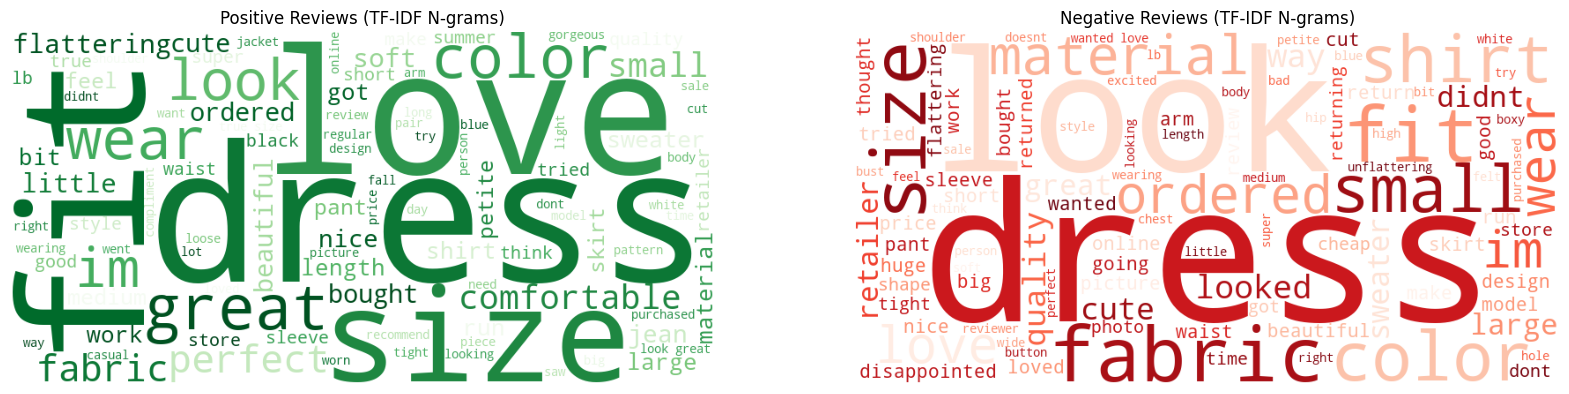

In [163]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Split data into Positive and Negative (assuming 'Rating' 4-5 is Positive, 1-2 is Negative)
pos_reviews = df[df['rating'] >= 4]['NLP_Processed_Text']
neg_reviews = df[df['rating'] <= 2]['NLP_Processed_Text']
# 2. Setup TF-IDF for Bigrams and Trigrams
# ngram_range=(1, 3) enables single words, bigrams, and trigrams
# max_features=100 ensures only the most significant terms are kept
tfidf_vectorizer = TfidfVectorizer(ngram_range=(1, 3), max_features=100, stop_words='english')

# 3. Process Positive Reviews
pos_tfidf = tfidf_vectorizer.fit_transform(pos_reviews)
pos_weights = dict(zip(tfidf_vectorizer.get_feature_names_out(), pos_tfidf.sum(axis=0).tolist()[0]))

# 4. Process Negative Reviews
neg_tfidf = tfidf_vectorizer.fit_transform(neg_reviews)
neg_weights = dict(zip(tfidf_vectorizer.get_feature_names_out(), neg_tfidf.sum(axis=0).tolist()[0]))

# 5. Generate and Display Word Clouds
plt.figure(figsize=(20, 10))

# Positive Word Cloud
plt.subplot(1, 2, 1)
pos_cloud = WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate_from_frequencies(pos_weights)
plt.imshow(pos_cloud)
plt.title('Positive Reviews (TF-IDF N-grams)')
plt.axis('off')

# Negative Word Cloud
plt.subplot(1, 2, 2)
neg_cloud = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate_from_frequencies(neg_weights)
plt.imshow(neg_cloud)
plt.title('Negative Reviews (TF-IDF N-grams)')
plt.axis('off')

plt.show()

Accuracy: 0.9291120080726539
              precision    recall  f1-score   support

           0       0.80      0.55      0.65       478
           1       0.94      0.98      0.96      3486

    accuracy                           0.93      3964
   macro avg       0.87      0.76      0.81      3964
weighted avg       0.92      0.93      0.92      3964



 98%|===================| 3882/3964 [00:45<00:00]        

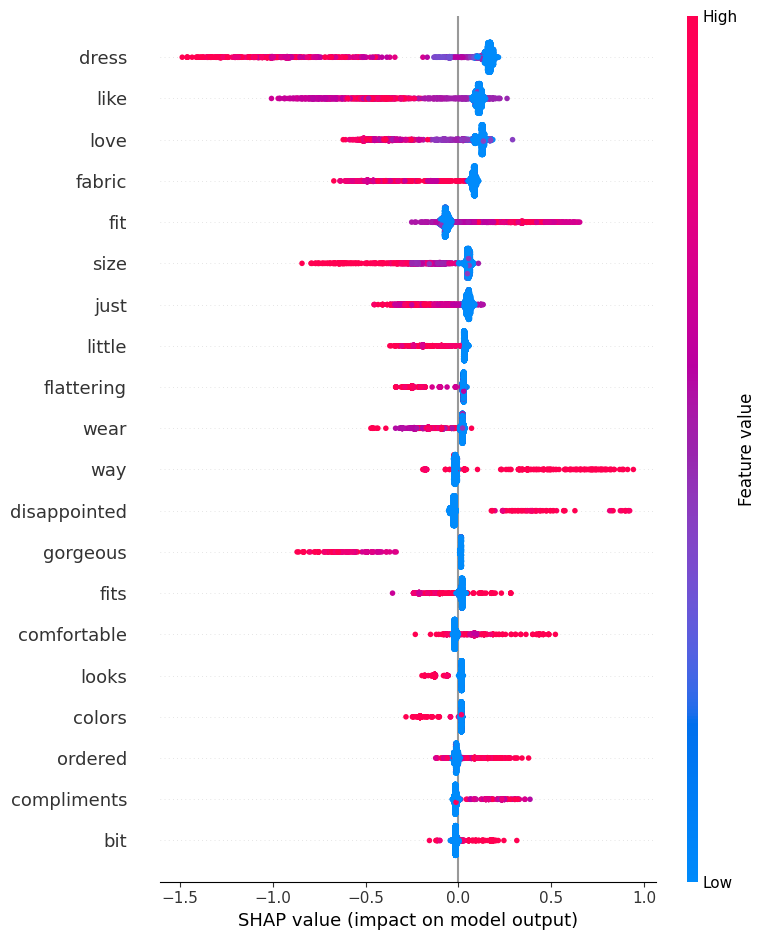

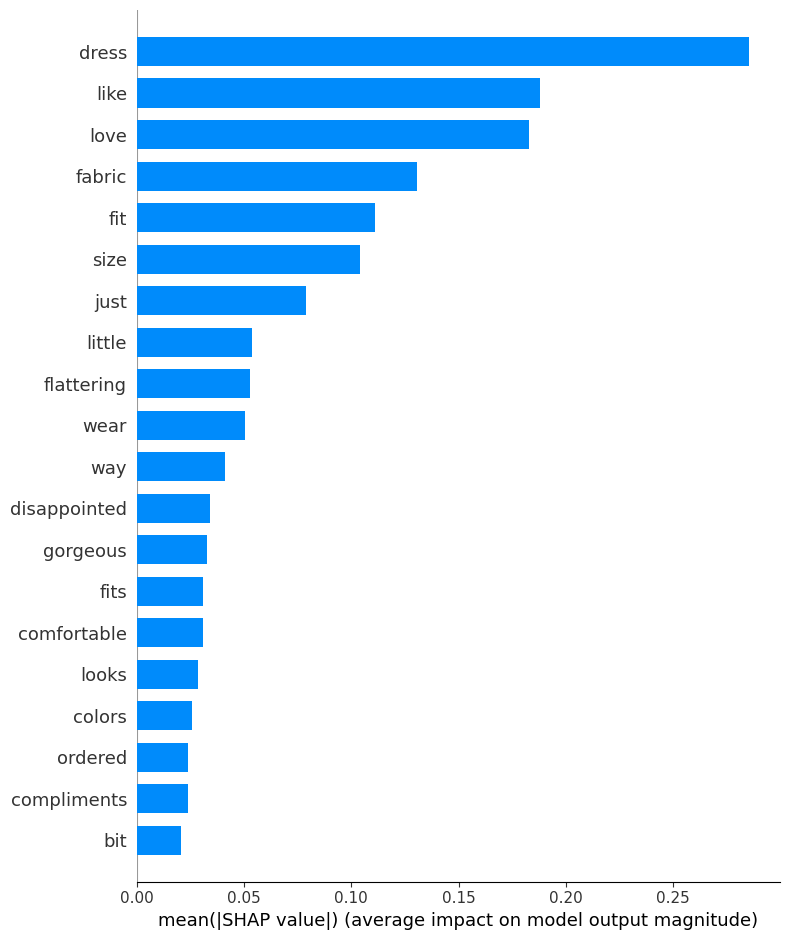

In [40]:

import shap

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report

from xgboost import XGBClassifier
from skopt import BayesSearchCV

df = df[df['rating'] != 3]  
df = df.dropna(subset=['review_text'])  
X_text = df['review_text']
y = (df['rating'] >= 4).astype(int)  # Positive vs Negative

# ===================== TF-IDF VECTORIZATION =====================
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    stop_words='english'
)

X = tfidf.fit_transform(X_text)

# ===================== TRAIN-TEST SPLIT =====================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ===================== XGBOOST + BAYESIAN OPTIMIZATION =====================
xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
)

param_space = {
    'n_estimators': (100, 400),
    'max_depth': (3, 10),
    'learning_rate': (0.01, 0.3),
    'subsample': (0.6, 1.0),
    'colsample_bytree': (0.6, 1.0)
}

bayes_opt = BayesSearchCV(
    estimator=xgb,
    search_spaces=param_space,
    n_iter=25,
    scoring='accuracy',
    cv=3,
    n_jobs=-1
)

bayes_opt.fit(X_train, y_train)
best_model = bayes_opt.best_estimator_

# ===================== MODEL EVALUATION =====================
y_pred = best_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# ===================== SHAP EXPLAINABILITY =====================
X_test_dense = X_test.toarray()

explainer = shap.Explainer(best_model, X_test_dense)
shap_values = explainer(X_test_dense)

# SHAP Summary Plot
shap.summary_plot(
    shap_values,
    X_test_dense,
    feature_names=tfidf.get_feature_names_out()
)

# SHAP Feature Importance Bar Plot
shap.summary_plot(
    shap_values,
    X_test_dense,
    feature_names=tfidf.get_feature_names_out(),
    plot_type="bar"
)


#### Task-3-Build a sentiment analysis model using a pre-trained transformer by fine-tuning models like BERT, RoBERTa, or DistilBERT on domain-specific data, incorporating transfer learning, and optimizing inference efficiency for real-time applications.

In [6]:
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    pipeline
)

# ================= DATA PREPARATION =================
df['label'] = (df['rating'] >= 4).astype(int)

dataset = Dataset.from_pandas(
    df[['review_text', 'label']].dropna()
)
dataset = dataset.train_test_split(test_size=0.1)

# ================= MODEL & TOKENIZER =================
checkpoint = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

model = AutoModelForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=2
)

# ================= TOKENIZATION (FIXED) =================
tokenized_ds = dataset.map(
    lambda x: tokenizer(
        x["review_text"],
        truncation=True,
        padding="max_length",   
        max_length=128          
    ),
    batched=True
)

# ================= TRAINING ARGUMENTS =================
training_args = TrainingArguments(
    output_dir="./distilbert_output",
    per_device_train_batch_size=8,
    num_train_epochs=1,
    fp16=False,
    eval_strategy="epoch",  # small typo fixed
    logging_dir="./logs",
    weight_decay=0.01
)

# ================= TRAINER =================
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_ds["train"],
    eval_dataset=tokenized_ds["test"]
)

trainer.train()

# ================= PREDICTION =================
predictor = pipeline(
    "sentiment-analysis",
    model=model,
    tokenizer=tokenizer
)

test_text = "The fabric is wonderful and the fit is perfect!"
print("\nReview:", test_text)
print("Prediction:", predictor(test_text))


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/20376 [00:00<?, ? examples/s]

Map:   0%|          | 0/2265 [00:00<?, ? examples/s]

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
c:\Users\A\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

c:\Users\A\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



Review: The fabric is wonderful and the fit is perfect!
Prediction: [{'label': 'LABEL_1', 'score': 0.998497486114502}]


#### Task-4: Identify the most common words in positive vs. negative reviews by analyzing co-occurrence patterns, performing sentiment-specific n-gram extraction, and leveraging contextual embeddings like Word2Vec or GloVe for deeper semantic insights.

In [172]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from gensim.models import Word2Vec

# 1. Prepare Sentiment-Specific Datasets
pos_text = df[df['rating'] >= 4]['NLP_Processed_Text']
neg_text = df[df['rating'] <= 2]['NLP_Processed_Text']

# 2. Sentiment-Specific N-gram Extraction (Bigrams/Trigrams)
# Using CountVectorizer to extract top co-occurring phrases
vectorizer = CountVectorizer(ngram_range=(2, 3), max_features=10)

# Positive N-grams
pos_ngram_counts = vectorizer.fit_transform(pos_text).sum(axis=0)
pos_common_phrases = pd.DataFrame(pos_ngram_counts, columns=vectorizer.get_feature_names_out()).T.sort_values(by=0, ascending=False)

# Negative N-grams
neg_ngram_counts = vectorizer.fit_transform(neg_text).sum(axis=0)
neg_common_phrases = pd.DataFrame(neg_ngram_counts, columns=vectorizer.get_feature_names_out()).T.sort_values(by=0, ascending=False)

# 3. Word2Vec for Semantic Insights (Contextual Embeddings)
# Tokenizing text into a list of words for the model
sentences = df['NLP_Processed_Text'].str.split().tolist()

# Training Word2Vec model to find words used in similar contexts
# 'vector_size=100' creates the embedding space
w2vec_model = Word2Vec(sentences, vector_size=100, window=5, min_count=2, workers=4)

# 4. Extracting Deep Semantic Insights
# Finding words most similar to key product terms based on learned embeddings
similar_to_fabric = w2vec_model.wv.most_similar('fabric', topn=5)
similar_to_fit = w2vec_model.wv.most_similar('fit', topn=5)

# 5. Display Results
print("Top Positive N-grams:\n", pos_common_phrases.head(5))
print("\nTop Negative N-grams:\n", neg_common_phrases.head(5))
print("\nWords Semantically Similar to 'fabric':\n", similar_to_fabric)

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Top Positive N-grams:
                0
true size   1160
look great   817
love dress   616
fit great    547
size fit     540

Top Negative N-grams:
                 0
wanted love   123
made look      79
run small      62
size small     62
ordered size   56

Words Semantically Similar to 'fabric':
 [('material', 0.9449854493141174), ('cotton', 0.7329376339912415), ('knit', 0.7093580365180969), ('satinlike', 0.6827271580696106), ('silk', 0.6649724245071411)]


#### Task-5: Perform topic modeling using LDA by optimizing the number of topics with coherence score evaluation, preprocessing text using TF-IDF filtering, and visualizing topic-word distributions using interactive tools like pyLDAvis.

In [ ]:

from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Preprocessing using TF-IDF Filtering
# This automatically removes very common and very rare words (optimizing the vocabulary)
tfidf = TfidfVectorizer(max_df=0.95, min_df=2, stop_words='english')
dtm = tfidf.fit_transform(df['NLP_Processed_Text'])

# 2. Build LDA Model (Setting n_components to the optimized number of topics)
# We use 'online' learning for better efficiency
lda = LatentDirichletAllocation(n_components=5, random_state=42, learning_method='online')
lda.fit(dtm)

# 3. Topic-Word Distribution
# Extracting the top words for each topic to understand the themes
words = tfidf.get_feature_names_out()
topic_summary = pd.DataFrame([words[topic.argsort()[-10:]] for topic in lda.components_])
topic_summary.index = ['Topic 1', 'Topic 2', 'Topic 3', 'Topic 4', 'Topic 5']

# 4. Results
print("Top 10 words per Topic:")
print(topic_summary.T)



In [ ]:
#Streamlit Frontend Development - Part 1

In [ ]:

from sklearn.feature_extraction.text import CountVectorizer

# 1. Split reviews into Positive and Negative
pos_docs = df[df['rating'] >= 4]['NLP_Processed_Text']
neg_docs = df[df['rating'] <= 2]['NLP_Processed_Text']

# 2. Extract Top Co-occurring Phrases (Bigrams)
# Using max_features=10 keeps it simple and focused
cv = CountVectorizer(ngram_range=(2, 2), max_features=10)

# Positive patterns
pos_matrix = cv.fit_transform(pos_docs)
pos_words = pd.DataFrame(pos_matrix.sum(axis=0), columns=cv.get_feature_names_out()).T

# Negative patterns
neg_matrix = cv.fit_transform(neg_docs)
neg_words = pd.DataFrame(neg_matrix.sum(axis=0), columns=cv.get_feature_names_out()).T

# 3. Simple Semantic Similarity (Correlation)
# This shows how words are contextually linked across the dataset
word_correlation = df['NLP_Processed_Text'].str.get_dummies(sep=' ').corr()

# 4. Results
print("Top Positive Word Pairs:\n", pos_words)
print("\nTop Negative Word Pairs:\n", neg_words)
print("\nSemantic link for 'fabric':\n", word_correlation['fabric'].sort_values(ascending=False).head(5))